In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import glob
plt.rcParams["font.family"] = "Times New Roman"
import dask.dataframe as dd

from pyproj import CRS
from cartopy import crs as ccrs
import matplotlib.colors as colors

### projections and world map ###
eckert_IV = CRS.from_proj4("+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m +no_defs")
robinson = ccrs.Robinson(central_longitude=0, globe=None)

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[world['continent']!='Antarctica'].reset_index(drop = True).rename(columns={'iso_a3':'iso3'})
GADM = gpd.read_file('/Users/Jasper/Documenten/DPhil_Oxford/DPhil_GIS/GADM/gadm36_0.shp').rename(columns = {'GID_0':'iso3'})
GADM = GADM[~GADM['iso3'].isin(['XAD','XCA','XCL','XKO','XNC','XPI','XSP','ATA'])]

import matplotlib.colors as colors

from scipy import stats
import statsmodels.api as sm

In [2]:
def risk_drought(likelihood):
    ### return likelihood (years), timescale (days), severity (0-1)
    if likelihood =='no':
        return np.nan, np.nan, np.nan
    else:
        return 40, 250, 0.33
    
def risk_EQ(likelihood):
    ### return likelihood (years), timescale (days), severity (0-1)
    if likelihood =='no':
        return np.nan, np.nan, np.nan
    else:
        return 2500, 365, 1
    
def add_risk_quantification(df):
    ### drought ###
    risk_index = 'drought'
    df['likelihood_'+risk_index], df['timescale_'+risk_index],df['severity_'+risk_index] =  zip(*df[risk_index].apply(risk_drought))
    
    ### EQ ##
    risk_index = 'EQ'
    df['likelihood_'+risk_index], df['timescale_'+risk_index],df['severity_'+risk_index] =  zip(*df[risk_index].apply(risk_EQ))

    return df

def derive_trade_at_risk(trade_iso3, risk_df):
    ### merge risk information ##
    trade_iso3 = trade_iso3.merge(risk_df, on = 'canal')
    
    ## value share total trade and maritime ##
    trade_iso3['v_share']= trade_iso3['v_canal']/trade_iso3['v']
    trade_iso3['v_share_mar']= trade_iso3['v_canal']/trade_iso3['v_sea_predict']

    ### list of risks ##
    risk_list = ['piracy','geopolitical','blockage','drought','EQ','TC','terrorist','conflict']
    
    ## loop over risks and quantify trade-at-risk ##
    ## trade-at-risk = trade (v or q) * (1/likelihood) * timescale (days-year) * severity (0-1)
    for risk in risk_list:
        trade_iso3['timescale_'+str(risk)] = trade_iso3['timescale_'+str(risk)].replace(np.nan, 0).astype(int)
        trade_iso3['trade_at_risk_'+str(risk)+'_v'] = trade_iso3['v_canal']*(1/trade_iso3['likelihood_'+str(risk)])*(trade_iso3['timescale_'+str(risk)]/365) * trade_iso3['severity_'+str(risk)]
        trade_iso3['trade_at_risk_'+str(risk)+'_q'] = trade_iso3['q_canal']*(1/trade_iso3['likelihood_'+str(risk)])*(trade_iso3['timescale_'+str(risk)]/365) * trade_iso3['severity_'+str(risk)]
        trade_iso3['revenue_at_risk_'+str(risk)] = trade_iso3['revenue_USD']*(1/trade_iso3['likelihood_'+str(risk)])*(trade_iso3['timescale_'+str(risk)]/365) * trade_iso3['severity_'+str(risk)]
        trade_iso3['trade_impacted_'+str(risk)] = trade_iso3['v_canal']*(trade_iso3['timescale_'+str(risk)]/365) * trade_iso3['severity_'+str(risk)]
 
    ## total ##
    trade_iso3['trade_at_risk_v'] = trade_iso3[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_terrorist_v','trade_at_risk_conflict_v','trade_at_risk_blockage_v','trade_at_risk_drought_v','trade_at_risk_EQ_v','trade_at_risk_TC_v']].sum(axis = 1)
    trade_iso3['trade_at_risk_q'] = trade_iso3[['trade_at_risk_piracy_q','trade_at_risk_geopolitical_q','trade_at_risk_terrorist_q','trade_at_risk_conflict_q','trade_at_risk_blockage_q','trade_at_risk_drought_q','trade_at_risk_EQ_q','trade_at_risk_TC_q']].sum(axis = 1)
    trade_iso3['revenue_at_risk'] = trade_iso3[['revenue_at_risk_piracy','revenue_at_risk_geopolitical','revenue_at_risk_terrorist','revenue_at_risk_conflict','revenue_at_risk_blockage','revenue_at_risk_drought','revenue_at_risk_EQ','revenue_at_risk_TC']].sum(axis = 1)
    trade_iso3['trade_impacted'] = trade_iso3[['trade_impacted_piracy','trade_impacted_geopolitical','trade_impacted_terrorist','trade_impacted_conflict','trade_impacted_blockage','trade_impacted_drought','trade_impacted_EQ','trade_impacted_TC']].sum(axis = 1)
    
    return trade_iso3
    

In [3]:
def return_delay(delay, VOT):
    val = 0
    for i in range(0,delay+1):
        val = val + i*VOT
    
    return val


In [4]:
def estimate_economic_cost(df, delay_cost, rerouting_cost, risk):
    sheet_names = ['Response_1days','Response_3days','Response_5days','Response_7days','Response_10days','Response_30days','Response_50days','Response_100days','Response_183days','Response_250days','Response_365days']
    economic_fraction = pd.DataFrame()
    for sheet in sheet_names:
        sheet_df = pd.read_excel('Chokepoint_risk_information/Chokepoint_datasheet_new.xlsx', sheet_name = sheet).rename(columns = {'Chokepoint':'canal'}).rename(columns = {'timescale':'timescale_'+risk})
        sheet_df['timescale_'+risk] = sheet_df['timescale_'+risk].astype(int)
        economic_fraction = pd.concat([economic_fraction, sheet_df],ignore_index = True, sort = False)

    df_new = df.merge(economic_fraction, on = ['canal','timescale_'+risk])
    df_new['delay_val_'+risk] = df_new.apply(lambda row: return_delay(row['delay'],0.01), axis=1)
     
    df_new['delay_USD_'+risk] = ((df_new['v_canal']/365)*(1/df_new['likelihood_'+str(risk)])* df_new['severity_'+str(risk)]) * (df_new['rerouting_km'] * 0.01/(30*24) * df_new['timescale_'+risk]  + df_new['delay_val_'+risk])
    df_new['reroute_USD_'+risk] = 2*df_new['trade_at_risk_'+str(risk)+'_q']*df_new['rerouting_km']*rerouting_cost
    df_new['lost_USD_'+risk] = df_new['trade_at_risk_'+str(risk)+'_v']*df_new['disrupted']
    df_new['revenue_USD_'+risk] = df_new['revenue_at_risk_'+str(risk)]

    df_new['total_loss_USD_'+risk] = df_new['delay_USD_'+risk] + df_new['reroute_USD_'+risk] + df_new['lost_USD_'+risk] + df_new['revenue_USD_'+risk]

    df_new = df_new.drop(columns = ['delay','rerouting_km','disrupted'])
    print(risk, df_new['total_loss_USD_'+risk].sum()/1e9, df_new['delay_val_'+risk].sum())
    
    
    df = df.merge(df_new[['canal','iso3','delay_USD_'+risk, 'reroute_USD_'+risk,'lost_USD_'+risk, 'revenue_USD_'+risk,'total_loss_USD_'+risk]], on = ['canal','iso3'], how = 'left')
    return df

In [5]:
def add_buffer(df, buffer_size):
    ## make gdf ##
    gdf =gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
    )

    gdf_buffer = gdf.copy()
    gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)
    gdf_buffer['number'] = 1
    
    return gdf_buffer

def add_buffer_gdf(gdf, buffer_size):
    ## make gdf ##
    gdf_buffer = gdf.copy()
    gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)
    gdf_buffer['number'] = 1
    
    return gdf_buffer

  
def lat_function(deg,min_sec,sign):
    if sign in ['N','S']:
        lat_degree = int(deg.split('°')[0])
        lat_minutes = int(min_sec.split('.')[0])
        lat_seconds = int(min_sec.split('.')[1].split('\'')[0])

        if sign == 'N':
            return lat_degree + lat_minutes/60 + lat_seconds/3600
        else:
            return -1*(lat_degree + lat_minutes/60 + lat_seconds/3600)

    else:
        return np.nan
    
def lon_function(deg,min_sec,sign):
    if sign in ['E','W']:
        lat_degree = int(deg.split('°')[0])
        lat_minutes = int(min_sec.split('.')[0])
        lat_seconds = int(min_sec.split('.')[1].split('\'')[0])

        if sign == 'E':
            return lat_degree + lat_minutes/60 + lat_seconds/3600
        else:
            return -1*(lat_degree + lat_minutes/60 + lat_seconds/3600)

    else:
        return np.nan
    
def read_incident_data(incident, cp, buffer_size):
    incident = incident[~incident['Coordinates'].isna()].reset_index(drop = True)
    incident = pd.concat([incident,incident['Coordinates'].str.split(' ', expand = True)], axis = 1)

    incident['latitude'] = incident.apply(lambda row: lat_function(row[0],row[1], row[2]), axis=1)
    incident['longitude'] = incident.apply(lambda row: lon_function(row[3],row[4], row[5]), axis=1)

    incident_gdf = add_buffer(df = incident, buffer_size = buffer_size)
    incident_gdf = incident_gdf[(incident_gdf['latitude'].notna()) & (incident_gdf['longitude'].notna())].reset_index(drop = True)

    incident_gdf = incident_gdf[incident_gdf['Casualty severity'].isin(['Marine incident','Very serious marine casualty'])].reset_index(drop = True)

    N_years = pd.to_datetime(incident['Occurrence date and time'], format = '%d/%m/%Y %H:%M').dt.year.nunique()

    ## cp intersect ##
    cp_incident = cp[['canal']].merge(gpd.overlay(cp, incident_gdf).groupby(['canal'])[['number']].sum().reset_index(), on = 'canal', how = 'left')
    cp_incident['number'] = np.where(cp_incident['canal'].isin(['Suez Canal','Panama Canal','Bosporus Strait']), cp_incident['number'], np.nan)
    cp_incident['number'] = np.where(cp_incident['canal']=='Suez canal', cp_incident['number']+1, cp_incident['number'])

    cp_incident['likelihood_blockage'] = 1/(cp_incident['number']/N_years)
    cp_incident['timescale_blockage'],cp_incident['severity_blockage'] = 3,1
    
    ### cp_event ##
    cp_event = gpd.overlay(cp, incident_gdf)
    cp_event['number'] = np.where(cp_event['canal'].isin(['Suez Canal','Panama Canal','Bosporus Strait']), 1, np.nan)
    cp_event = cp_event[['canal','number']].copy().dropna()
    cp_event = pd.concat([cp_event, pd.DataFrame({'canal':['Suez Canal'],'number':[1]})], ignore_index = True, sort = False)
    cp_event['likelihood_blockage'] = (N_years)
    cp_event['timescale_blockage'],cp_event['severity_blockage'] = 3,1
    
                                
    ## return 
    return incident_gdf, cp_incident, cp_event
    
    
def read_conflict_data(conflict, cp, buffer_size):
    ## extract only deadly conflict ##
    conflict = conflict[(conflict['latitude'].notna()) & (conflict['longitude'].notna()) & (conflict['best']>10)].reset_index(drop = True)

    conflict['government_a'], conflict['government_b']= conflict['side_a'].str.contains('Government'),conflict['side_b'].str.contains('Government')
    conflict['interstate'] = np.where(((conflict['government_a']==True) & (conflict['government_b']==True)), 1,0)

    ## remove interstate conflict ##
    conflict = conflict[conflict['interstate']==0].reset_index(drop = True)

    ## make gdf ##
    conflict_gdf = add_buffer(df = conflict, buffer_size = buffer_size)

    ## cp intersect ##
    cp_conflict = cp[['canal']].merge(gpd.overlay(cp, conflict_gdf).groupby(['canal'])[['number','best']].sum().reset_index(), on = 'canal', how = 'left')
    cp_conflict['likelihood_conflict'] = 1/(cp_conflict['number']/conflict['year'].nunique())
    cp_conflict['timescale_conflict'],cp_conflict['severity_conflict'] = 10,0.2

    print(conflict['year'].min(), conflict['year'].max(), conflict['year'].nunique(), cp_conflict['number'].sum())
    
    ### cp event ##
    cp_event = gpd.overlay(cp, conflict_gdf)[['canal']].copy()
    cp_event['number'] = 1
    cp_event['likelihood_conflict'] = conflict['year'].nunique()
    cp_event['timescale_conflict'], cp_event['severity_conflict'] = 10,0.2
    
    return conflict_gdf, cp_conflict, cp_event


def read_terror_data(terror, cp, buffer_size):
    ## extract only deadly conflict ##
    terror = terror[(terror['latitude'].notna()) & (terror['longitude'].notna()) & (terror['attacktype1'].isin([3,4,7])) & (terror['nkill']>5)].reset_index(drop = True).replace(np.nan, 0)

    ## make gdf ##
    terror_gdf = add_buffer(df = terror, buffer_size = buffer_size)

    ## cp intersect ##
    cp_terror= cp[['canal']].merge(gpd.overlay(cp[['canal','geometry']], terror_gdf).groupby(['canal'])[['number','nkill']].sum().reset_index(), on = 'canal', how = 'left')
    cp_terror['likelihood_terrorist'] = 1/(cp_terror['number']/terror['iyear'].nunique())
    #cp_terror['rp_terror'] = (1/cp_terror['likelihood_terrorist']).replace(np.inf, np.nan)
    cp_terror['timescale_terrorist'], cp_terror['severity_terrorist'] = 10, 0.2

    print(terror['iyear'].min(), terror['iyear'].max(), terror['iyear'].nunique(),cp_terror['number'].sum())
    
    ### cp event ##
    cp_event = gpd.overlay(cp, terror_gdf)[['canal']].copy()
    cp_event['number'] = 1
    cp_event['likelihood_terrorist'] = terror_gdf['iyear'].nunique()
    cp_event['timescale_terrorist'], cp_event['severity_terrorist'] = 10,0.2
    
    
    return terror_gdf, cp_terror, cp_event

def read_piracy_data(piracy, cp, buffer_size):
    piracy = piracy[piracy['hostilityt']>0].reset_index(drop = True)
    ## make gdf ##
    piracy_gdf = add_buffer_gdf(gdf = piracy, buffer_size = buffer_size)

    ## cp intersect ##
    cp_piracy= cp[['canal']].merge(gpd.overlay(cp[['canal','geometry']], piracy_gdf).groupby(['canal'])[['number']].sum().reset_index(), on = 'canal', how = 'left')
    cp_piracy['likelihood_piracy'] = 1/(cp_piracy['number']/piracy['year'].nunique())
    #cp_piracy['rp_piracy'] = (1/cp_piracy['likelihood_piracy']).replace(np.inf, np.nan)
    cp_piracy['timescale_piracy'], cp_piracy['severity_piracy'] = 14, 1/100
    print(piracy['year'].min(), piracy['year'].max(), piracy['year'].nunique(), cp_piracy['number'].sum())
    
    ### cp event ##
    cp_event = gpd.overlay(cp, piracy_gdf)[['canal']].copy()
    cp_event['number'] = 1
    cp_event['likelihood_piracy'] = piracy['year'].nunique()
    cp_event['timescale_piracy'],cp_event['severity_piracy'] = 14, 1/100
    
    
    return piracy_gdf, cp_piracy, cp_event

def read_interstate_conflict_data(cp, buffer_size, thres_level, year_thres):
    dispute = pd.read_csv('Data/MID-5-Data-and-Supporting-Materials/MIDA 5.0.csv').sort_values(by = 'dispnum')
    incident = pd.read_csv('Data/MID-5-Data-and-Supporting-Materials/MIDI 5.0.csv').sort_values(by = 'dispnum')

    dispute = dispute[(dispute['hostlev']>thres_level)].reset_index(drop = True)
    incident = incident[(incident['hostlev']>thres_level)].reset_index(drop = True)
    dispute = dispute[~dispute['dispnum'].isin(incident['dispnum'])].reset_index(drop = True)

    ### disputes ###
    dispute_loc = pd.read_csv('Data/MIDLOC_2.1/MIDLOCA_2.1.csv', usecols=  ['year','dispnum','midloc2_xlongitude','midloc2_ylatitude'],encoding='unicode_escape').sort_values(by = 'dispnum').dropna().rename(columns = {'midloc2_xlongitude':'lon','midloc2_ylatitude':'lat'})
    dispute_loc = dispute_loc[dispute_loc['dispnum'].isin(dispute['dispnum'].unique())].reset_index(drop = True)

    dispute_loc = dispute_loc[dispute_loc['year']>=year_thres].reset_index(drop = True)
    dispute_loc_gdf = gpd.GeoDataFrame(dispute_loc, geometry=gpd.points_from_xy(dispute_loc.lon, dispute_loc.lat), crs="EPSG:4326")
    dispute_loc_gdf = dispute_loc_gdf.merge(dispute, on = ['dispnum'])
    dispute_loc_gdf['duration'] = (dispute_loc_gdf['maxdur']+dispute_loc_gdf['mindur'])/2
    dispute_loc_gdf = dispute_loc_gdf[dispute_loc_gdf['duration']>0].reset_index(drop = True)

    ### indicidents ##
    incident_loc = pd.read_csv('Data/MIDLOC_2.1/MIDLOCI_2.1.csv', usecols=  ['year','dispnum','incidnum','midloc2_xlongitude','midloc2_ylatitude'],encoding='unicode_escape').sort_values(by = 'dispnum').dropna().rename(columns = {'midloc2_xlongitude':'lon','midloc2_ylatitude':'lat'})
    incident_loc = incident_loc[incident_loc['dispnum'].isin(incident_loc['dispnum'].unique())].reset_index(drop = True)
    incident_loc = incident_loc[incident_loc['year']>=year_thres].reset_index(drop = True)
    incident_loc_gdf = gpd.GeoDataFrame(incident_loc, geometry=gpd.points_from_xy(incident_loc.lon, incident_loc.lat), crs="EPSG:4326")
    incident_loc_gdf = incident_loc_gdf.merge(incident, on = ['dispnum','incidnum'])
    incident_loc_gdf = incident_loc_gdf[incident_loc_gdf['duration']>0].reset_index(drop = True)

    MIS_data = pd.concat([dispute_loc_gdf, incident_loc_gdf], ignore_index = True, sort = False)

    ## make gdf ##
    MIS_data_gdf = add_buffer_gdf(gdf = MIS_data, buffer_size = buffer_size)
    MIS_data_gdf_plot = add_buffer_gdf(gdf = MIS_data, buffer_size = 50)

    N_years = (2014-year_thres)
    print(N_years)
    
    ###
    check = gpd.overlay(cp, MIS_data_gdf)
    check  = check[check['dispnum']!=3901].reset_index(drop = True)
    check['severity'] = np.where(check['hostlev']==3, 0.1, 0.5)
    check['severity'] = np.where(check['hostlev']==5, 1, check['severity'])

    cp_MIS = cp[['canal']].merge(check.groupby(['canal'])[['number','duration','severity']].sum().reset_index(), on = 'canal', how = 'left')
    cp_MIS['number'] = np.where(cp_MIS['canal']=='Bab el-Mandeb Strait', cp_MIS['number']+1,cp_MIS['number'])
    cp_MIS['duration'] = np.where(cp_MIS['canal']=='Bab el-Mandeb Strait', cp_MIS['duration']+365,cp_MIS['duration'])
    cp_MIS['severity'] = np.where(cp_MIS['canal']=='Bab el-Mandeb Strait', cp_MIS['severity']+0.67,cp_MIS['severity'])
    
    cp_MIS['likelihood_geopolitical'] = 1/(cp_MIS['number']/N_years)
    cp_MIS['timescale_geopolitical'] = (cp_MIS['duration']/cp_MIS['number'])
    cp_MIS['severity_geopolitical'] = (cp_MIS['severity']/cp_MIS['number'])
    
    cp_MIS['index'] = (1/cp_MIS['likelihood_geopolitical'])* cp_MIS['timescale_geopolitical']
    
    ### cp events ##
    cp_event =  check[['canal','severity','duration']].copy()
    cp_event = pd.concat([cp_event, pd.DataFrame({'canal':['Bab el-Mandeb Strait'],'duration':[365],'severity':[0.67]})], ignore_index = True, sort = False)
    cp_event['number'] = 1
    cp_event['likelihood_geopolitical'] = N_years
    cp_event = cp_event.rename(columns = {'duration':'timescale_geopolitical','severity':'severity_geopolitical'})
    
    return MIS_data_gdf_plot, cp_MIS, cp_event

def read_TC_events(TC_events, cp):
    TC_likelihood = (1/(TC_events.groupby(['canal'])['ID_event'].count()/10000)).reset_index().rename(columns = {'ID_event':'likelihood_TC'})

    TC_risk = cp[['canal']].merge(TC_likelihood, on = ['canal'], how = 'left')
    TC_risk = TC_risk.merge(TC_events.groupby(['canal'])['duration_days'].mean().reset_index().rename(columns = {'duration_days':'timescale_TC'}), on = ['canal'], how = 'left')
    TC_risk['severity_TC'] = 1
    
    ### cp event ##
    cp_event = TC_events.copy()
    cp_event['number'] = 1
    cp_event['likelihood_TC'] = 10000
    cp_event['timescale_TC'],cp_event['severity_TC'] = cp_event['duration_days'], 1
    
    return TC_risk, cp_event[['canal','number','likelihood_TC','timescale_TC','severity_TC']].copy()


In [6]:
### chokepoint shapefile ##
cp = gpd.read_file('/Users/Jasper/Documenten/AIS_extraction/Shapefiles/Canals_mapping.shp')
cp = cp.replace({'Suez':'Suez Canal','Panama':'Panama Canal','Turkish_Straits':'Bosporus Strait','Bab el-Mandeb':'Bab el-Mandeb Strait','Gibraltar':'Gibraltar Strait','Oresund':'Oresund Strait'})
cp['val'] = cp.index.to_series().apply(lambda x: chr(ord('a') + x)).str.lower()
cp = cp.rename(columns = {'Name':'canal'})

In [7]:
#### READ HAZARD DATASETS ###
### read Incidents data  ###
incident = pd.read_csv('Data/Accidents/GISIS-MCIR-20240807-122212.csv')
incident_gdf, cp_incident, cp_incident_event = read_incident_data(incident, cp, buffer_size = 10)

print(cp_incident['number'].sum())

## read Conflict data ##
conflict = pd.read_csv('Data/Conflict/GEDEvent_v24_1.csv',low_memory=False)[['id','year','type_of_violence','country','adm_1','adm_2','side_a','side_b','latitude','longitude','best']].copy()
conflict_gdf, cp_conflict, cp_conflict_event = read_conflict_data(conflict, cp, buffer_size = 50)

## read Terrorist attack data ##
terror = pd.read_excel('Data/Terrorist/globalterrorismdb_0522dist.xlsx', sheet_name = 'Subset')
terror_gdf, cp_terror, cp_terror_event = read_terror_data(terror, cp, buffer_size = 50)

## read Piract attack data ##
piracy = gpd.read_file('Data/Piracy/Asam_data_download/All ASAM Events.shp')
piracy_gdf, cp_piracy, cp_piracy_event = read_piracy_data(piracy, cp, buffer_size = 50) 

#### Militarized Interstate Dispute data ##
buffer_size = 200 ##km
thres_level = 2
year_thres = 1974
#year_thres = 1950

MIS_data_gdf_plot, cp_MIS, cp_MIS_event = read_interstate_conflict_data(cp, buffer_size, thres_level, year_thres)

print(cp_MIS['number'].sum())

### TC events ##
TC_events = pd.read_csv('Data/TC_events/cat1_event_database.csv')

cp_TC, cp_TC_event = read_TC_events(TC_events, cp)

/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2033383410.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)


12.0


/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2033383410.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)


1989 2023 35 96.0


/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2033383410.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)


1970 2020 50 39.0


/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2033383410.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)


1978 2024 46 820.0
40
114.0


/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2033383410.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)
/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2033383410.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(buffer_size/100)


In [8]:
cp_TC_event['timescale_TC'].median()
#cp_TC_event['timescale_TC'].quantile(0.99)

2.625

/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/2970561383.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  incident_gdf.buffer(0.4).plot(color = 'darkorange', ax = ax, label = 'Incidents events', zorder = 1)


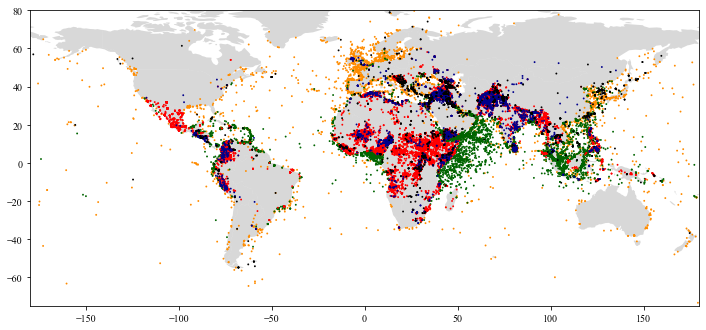

In [9]:
fig, ax = plt.subplots(figsize = (12,6))
world.plot(color = 'grey', alpha = 0.3, ax = ax, zorder = 0)
#cp.buffer(0.5).plot(color = 'navy', alpha = 0.8, ax = ax)

MIS_data_gdf_plot.plot(color = 'black', ax = ax, label = 'Geopolitical conflict events', alpha = 1, zorder = 5)
incident_gdf.buffer(0.4).plot(color = 'darkorange', ax = ax, label = 'Incidents events', zorder = 1)
piracy_gdf.plot(color = 'darkgreen', ax = ax, label = 'Piracy events', zorder = 2)
conflict_gdf.plot(color = 'red', ax = ax, label = 'Intrastate violent conflict', zorder = 3)
terror_gdf.plot(color = 'darkblue', ax = ax, label = 'Terrorist attacks', zorder = 4)
plt.ylim(-75, 80); plt.xlim(-180,180)
#plt.legend()
plt.savefig('Output/event_database_maritime.png', dpi = 500, bbox_inches = 'tight')

/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/1682465338.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cp.buffer(0.5).plot(color = 'navy', alpha = 0.8, ax = ax)
/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/1682465338.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plt.text(cp.geometry.centroid.x.iloc[i], 2+cp.geometry.centroid.y.iloc[i], cp.val.iloc[i], fontsize = 14)
/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/1682465338.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plt.text(cp.geometry.centroid.x

/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/1682465338.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plt.text(cp.geometry.centroid.x.iloc[i], 2+cp.geometry.centroid.y.iloc[i], cp.val.iloc[i], fontsize = 14)
/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/1682465338.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plt.text(cp.geometry.centroid.x.iloc[i], 2+cp.geometry.centroid.y.iloc[i], cp.val.iloc[i], fontsize = 14)
/var/folders/q8/84v3h_yd4s10h5nyys6t9qyw0000gn/T/ipykernel_32733/1682465338.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before 

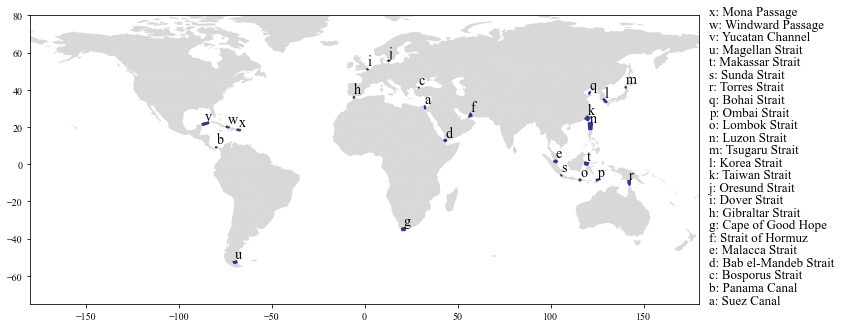

In [10]:
fig, ax = plt.subplots(figsize = (12,6))
world.plot(color = 'grey', alpha = 0.3, ax = ax)
cp.buffer(0.5).plot(color = 'navy', alpha = 0.8, ax = ax)
for i in range(0, len(cp)):
    plt.text(cp.geometry.centroid.x.iloc[i], 2+cp.geometry.centroid.y.iloc[i], cp.val.iloc[i], fontsize = 14)
    
plt.ylim(-75, 80); plt.xlim(-180,180)

y_val = np.linspace(-75,80,24)
x_val = [185]*24

for y,x,i in zip(y_val, x_val, range(0, len(cp))):
    plt.text(x, y, cp.val.iloc[i]+': '+cp.canal.iloc[i], fontsize = 13)
plt.savefig('Figures/chokepoints_maritime.png', dpi = 500, bbox_inches = 'tight')   

In [11]:
path_infra = '/Users/Jasper/Documenten/Population_infrastructure_data/Infrastructure/'

### Input parameters ##
V_avg = 16 ## knots

### chokepoints ### 
import_iso3 = pd.read_csv('../Maritime_Chokepoints/Output/country_import_dependency.csv')
import_iso3['q_canal_import'], import_iso3['v_canal_import'] = import_iso3['q_canal'], import_iso3['v_canal']
import_iso3['q_sea_import'], import_iso3['v_sea_import'] = import_iso3['q_sea_predict'], import_iso3['v_sea_predict']

export_iso3 = pd.read_csv('../Maritime_Chokepoints/Output/country_export_dependency.csv')
export_iso3['q_canal_export'], export_iso3['v_canal_export'] = export_iso3['q_canal'], export_iso3['v_canal']
export_iso3['q_sea_export'], export_iso3['v_sea_export'] = export_iso3['q_sea_predict'], export_iso3['v_sea_predict']

trade_iso3 = pd.concat([import_iso3, export_iso3]).groupby(['iso3','canal'])[['q','v','q_sea_predict','v_sea_predict','q_sea_import','v_sea_import','q_sea_export','v_sea_export','q_canal','v_canal','q_canal_import','q_canal_export','v_canal_import','v_canal_export']].sum().reset_index()
trade_iso3['canal'] = trade_iso3['canal'].replace({'Suez canal':'Suez Canal'})

### add share q through canal ##
share_global = trade_iso3.groupby(['canal'])[['q_canal','q_sea_predict']].sum().reset_index()
share_global['share_q'] = 100*(share_global['q_canal']/share_global['q_sea_predict'])

cp_volume_share = pd.read_csv('Data/Chokepoint_volume/cp_volume_share.csv')
## add predicted volume ##
share_global = share_global.merge(cp_volume_share[['canal','capacity']], on = 'canal')

trade_iso3 = trade_iso3.merge(share_global[['canal','share_q']], on = 'canal')

## revenue ##
## 7.9e9 ## revenue Suez Canal Authority ##
## 5e9 ## revenue Panama Canal Authority ##
trade_iso3['revenue_USD'] = np.where(((trade_iso3['canal'].isin(['Bab el-Mandeb Strait','Suez Canal'])) &(trade_iso3['iso3']=='EGY')), 7.9e9,0) 
trade_iso3['revenue_USD'] = np.where(((trade_iso3['canal'].isin(['Panama Canal'])) &(trade_iso3['iso3']=='PAN')), 5e9,trade_iso3['revenue_USD'])

### risk information
risk_occurrence = pd.read_excel('Chokepoint_risk_information/Chokepoint_datasheet_new.xlsx', sheet_name = 'Risk_classification', skiprows = [0]).rename(columns = {'Chokepoint':'canal'})
risk_occurrence['EQ'] = np.where(risk_occurrence['canal']=='Panama Canal', 'yes','no')

risk_occurrence = risk_occurrence[['canal','Drought','EQ','reroute_km']].copy().rename(columns = {'Drought':'drought'})
risk_occurrence['reroute_days'] = risk_occurrence['reroute_km']/ (V_avg * 1.85 * 24) ### average speed 

## add risk 
risk_occurrence = add_risk_quantification(df = risk_occurrence)

### merge conflict and terrorist ##
risk_occurrence = risk_occurrence.merge(cp_conflict[['canal','likelihood_conflict','timescale_conflict','severity_conflict']], on = 'canal')
risk_occurrence = risk_occurrence.merge(cp_terror[['canal','likelihood_terrorist','timescale_terrorist','severity_terrorist']], on = 'canal')
risk_occurrence = risk_occurrence.merge(cp_piracy[['canal','likelihood_piracy','timescale_piracy','severity_piracy']], on = 'canal')
risk_occurrence = risk_occurrence.merge(cp_incident[['canal','likelihood_blockage','timescale_blockage','severity_blockage']], on = 'canal')
risk_occurrence = risk_occurrence.merge(cp_MIS[['canal','likelihood_geopolitical','timescale_geopolitical','severity_geopolitical']], on = 'canal')
risk_occurrence = risk_occurrence.merge(cp_TC, on = 'canal')

### derive trade-at risk ###
trade_iso3_risk = derive_trade_at_risk(trade_iso3, risk_df = risk_occurrence)

In [12]:
risk_occurrence

,canal,drought,EQ,reroute_km,reroute_days,likelihood_drought,timescale_drought,severity_drought,likelihood_EQ,timescale_EQ,...,severity_piracy,likelihood_blockage,timescale_blockage,severity_blockage,likelihood_geopolitical,timescale_geopolitical,severity_geopolitical,likelihood_TC,timescale_TC,severity_TC
0,Bab el-Mandeb Strait,no,no,9000,12.668919,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,2.222222,37.666667,0.442778,285.714286,2.653571,1
1,Bosporus Strait,no,no,0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.01,2.375000,3,1,20.000000,4.500000,0.300000,NaN,NaN,1
2,Cape of Good Hope,no,no,1000,1.407658,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,NaN,NaN,NaN,2500.000000,2.218750,1
3,Dover Strait,no,no,2500,3.519144,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,NaN,NaN,NaN,1000.000000,2.125000,1
4,Gibraltar Strait,no,no,9000,12.668919,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,13.333333,5.666667,0.233333,34.722222,2.227431,1
5,Korea Strait,no,no,1000,1.407658,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,3.076923,7.000000,0.192308,0.958865,2.537707,1
6,Malacca Strait,no,no,1500,2.111486,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,40.000000,37.000000,0.500000,NaN,NaN,1
7,Oresund Strait,no,no,0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,NaN,NaN,NaN,NaN,NaN,1
8,Panama Canal,yes,yes,12000,16.891892,40.0,250.0,0.33,2500.0,365.0,...,0.01,6.333333,3,1,40.000000,198.000000,0.500000,98.039216,2.515931,1
9,Strait of Hormuz,no,no,0,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.01,NaN,3,1,5.000000,8.375000,0.400000,104.166667,2.622396,1


In [13]:
risk_occurrence[['canal','timescale_drought','timescale_EQ','timescale_geopolitical','timescale_terrorist','timescale_conflict','timescale_piracy','timescale_TC']]

,canal,timescale_drought,timescale_EQ,timescale_geopolitical,timescale_terrorist,timescale_conflict,timescale_piracy,timescale_TC
0,Bab el-Mandeb Strait,NaN,NaN,37.666667,10,10,14,2.653571
1,Bosporus Strait,NaN,NaN,4.500000,10,10,14,NaN
2,Cape of Good Hope,NaN,NaN,NaN,10,10,14,2.218750
3,Dover Strait,NaN,NaN,NaN,10,10,14,2.125000
4,Gibraltar Strait,NaN,NaN,5.666667,10,10,14,2.227431
5,Korea Strait,NaN,NaN,7.000000,10,10,14,2.537707
6,Malacca Strait,NaN,NaN,37.000000,10,10,14,NaN
7,Oresund Strait,NaN,NaN,NaN,10,10,14,NaN
8,Panama Canal,250.0,365.0,198.000000,10,10,14,2.515931
9,Strait of Hormuz,NaN,NaN,8.375000,10,10,14,2.622396


In [14]:
risk_occurrence[['canal','likelihood_drought','likelihood_EQ','likelihood_geopolitical','likelihood_terrorist','likelihood_conflict','likelihood_piracy','likelihood_TC']]

,canal,likelihood_drought,likelihood_EQ,likelihood_geopolitical,likelihood_terrorist,likelihood_conflict,likelihood_piracy,likelihood_TC
0,Bab el-Mandeb Strait,NaN,NaN,2.222222,3.571429,0.673077,0.255556,285.714286
1,Bosporus Strait,NaN,NaN,20.000000,3.571429,2.333333,46.000000,NaN
2,Cape of Good Hope,NaN,NaN,NaN,NaN,NaN,NaN,2500.000000
3,Dover Strait,NaN,NaN,NaN,50.000000,35.000000,NaN,1000.000000
4,Gibraltar Strait,NaN,NaN,13.333333,NaN,NaN,46.000000,34.722222
5,Korea Strait,NaN,NaN,3.076923,NaN,NaN,NaN,0.958865
6,Malacca Strait,NaN,NaN,40.000000,NaN,NaN,0.096033,NaN
7,Oresund Strait,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Panama Canal,40.0,2500.0,40.000000,50.000000,35.000000,4.600000,98.039216
9,Strait of Hormuz,NaN,NaN,5.000000,NaN,NaN,1.277778,104.166667


In [15]:
### event database for remaining hazards ##
cp_EQ_event = risk_occurrence[['canal','likelihood_EQ','timescale_EQ','severity_EQ']].dropna()
cp_drought_event = risk_occurrence[['canal','likelihood_drought','timescale_drought','severity_drought']].dropna()

### baseline ##
econ_risk = risk_occurrence[['canal']].copy()
econ_iso3_risk = trade_iso3_risk[['canal','iso3']].drop_duplicates().reset_index(drop = True)

### parameters ##
#delay_cost = 0.01 ## 1% of trade value per day
rerouting_cost = 0.003 ## per USD per t-km
#T_int = 20 ## 20 day inventories

risk_list = ['piracy','geopolitical','blockage','drought','EQ','TC','terrorist','conflict']
df_list = [cp_piracy_event, cp_MIS_event,cp_incident_event, cp_drought_event, cp_EQ_event, cp_TC_event, cp_terror_event, cp_conflict_event]

for risk, df in zip(risk_list, df_list):
    df_inv_impact = pd.DataFrame()
    for T_int, frac, delay_cost in zip([7, 25, 60], [0.15, 0.5, 0.35], [0.01, 0.01, 0.01]):
        print(risk, len(df), T_int)
        df_inv = df.merge(trade_iso3, on = 'canal').merge(risk_occurrence[['canal','reroute_days','reroute_km']], on = 'canal')
        df_inv['v_canal_import'] = df_inv['v_canal_import']*frac
        df_inv['q_canal_import'] = df_inv['q_canal_import']*frac
        df_inv['q_sea_import'] = df_inv['q_sea_import']*frac
        df_inv['v_sea_import'] = df_inv['v_sea_import']*frac
        df_inv['revenue_USD'] = df_inv['revenue_USD']*frac

        ### affected days ##
        df_inv['reroute_'+risk] = np.where((df_inv['reroute_days']>0)&(df_inv['timescale_'+risk]>df_inv['reroute_days']), 1, 0)
        df_inv['delay_'+risk] = np.where(df_inv['reroute_'+risk]==1,0,1)

        df_inv['delay_days_'+risk] = np.where(df_inv['reroute_'+risk]==1,df_inv['reroute_days'],df_inv['timescale_'+risk])
        df_inv['lost_days_'+risk] = np.where(((df_inv['delay_days_'+risk]>T_int)&(df_inv['delay_'+risk]==1)), (df_inv['timescale_'+risk]-T_int), 0)
        df_inv['lost_days_'+risk] = np.where(((df_inv['delay_days_'+risk]>T_int)&(df_inv['reroute_'+risk]==1)), (df_inv['reroute_days']-T_int), df_inv['lost_days_'+risk])

        df_inv['delay_days_'+risk] = np.where(df_inv['delay_days_'+risk]>T_int, T_int, df_inv['delay_days_'+risk])

        ### delays days - calculation ##
        df_inv['delay_days_'+risk] = df_inv['delay_days_'+risk].astype(int)
        df_inv['delay_days_'+risk] = df_inv.apply(lambda row: return_delay(row['delay_days_'+risk], delay_cost), axis=1)


        ### estimate USD ##
        df_inv['delay_USD_'+risk] = ((df_inv['v_canal_import']/365)*(1/df_inv['likelihood_'+str(risk)])* df_inv['severity_'+str(risk)]) * df_inv['delay_days_'+risk]
        df_inv['lost_USD_'+risk] = ((df_inv['v_canal_import']/365)*(1/df_inv['likelihood_'+str(risk)])* df_inv['severity_'+str(risk)]) * df_inv['lost_days_'+risk]
        df_inv['revenue_USD_'+risk] = df_inv['revenue_USD']*(1/df_inv['likelihood_'+str(risk)])*(df_inv['timescale_'+str(risk)]/365) * df_inv['severity_'+str(risk)]
        df_inv['reroute_USD_'+risk] = df_inv['reroute_'+risk] * ((df_inv['q_canal_import']/365)*(1/df_inv['likelihood_'+str(risk)])* df_inv['severity_'+str(risk)])*df_inv['reroute_km']*rerouting_cost * df_inv['timescale_'+str(risk)]

        if risk in ['geopolitical']:
            df_inv['war_premium_USD_'+risk] = (df_inv['v_canal_import']/365) * (1/df_inv['likelihood_'+str(risk)]) * (1-df_inv['severity_'+str(risk)]) * df_inv['timescale_'+str(risk)] * (1/100)
        elif risk in ['terrorist','conflict', 'piracy']:
            df_inv['war_premium_USD_'+risk] = (df_inv['v_canal_import']/365) * (1/df_inv['likelihood_'+str(risk)]) * (1-df_inv['severity_'+str(risk)]) * df_inv['timescale_'+str(risk)] * (0.1/100)
        else:
            df_inv['war_premium_USD_'+risk] = 0

        drop_columns = cp_volume_share.columns[1:]
        df_inv = df_inv.merge(cp_volume_share, on = 'canal')
        df_inv['capacity_lost_per_day_cargo_'+risk] = df_inv['reroute_'+risk]*df_inv['share_capacity_tanker']*df_inv['severity_'+str(risk)]  * df_inv['reroute_days']/365
        df_inv['capacity_lost_per_day_tanker_'+risk] = df_inv['reroute_'+risk]*df_inv['share_capacity_cargo']*df_inv['severity_'+str(risk)]  * df_inv['reroute_days']/365

        df_inv['price_increase_per_day_'+risk] = (df_inv['capacity_lost_per_day_cargo_'+risk] * 376) #* df_inv['capacity_cargo'])/df_inv['capacity']

        df_inv['shipping_price_USD_'+risk] = (1/df_inv['likelihood_'+str(risk)]) * df_inv['reroute_'+risk] * rerouting_cost * (df_inv['price_increase_per_day_'+risk]) * (df_inv['timescale_'+str(risk)]) * (df_inv['q_sea_import']*0.3*10000)/(365)
        df_inv = df_inv.drop(columns = drop_columns)

        ### total - no shipping price ##
        df_inv['total_loss_USD_'+risk] = df_inv[['delay_USD_'+risk,'lost_USD_'+risk,'revenue_USD_'+risk,'reroute_USD_'+risk,'war_premium_USD_'+risk]].replace(np.nan, 0).sum(axis = 1)
        df_inv_impact = pd.concat([df_inv_impact, df_inv], ignore_index = True, sort = False)
        del df_inv
        
    sum_iso3 = df_inv_impact.groupby(['iso3','canal'])[['delay_USD_'+risk,'lost_USD_'+risk,'revenue_USD_'+risk,'reroute_USD_'+risk,'war_premium_USD_'+risk,'shipping_price_USD_'+risk,'total_loss_USD_'+risk]].sum().reset_index()
    sum_all = df_inv_impact.groupby(['canal'])[['delay_USD_'+risk,'lost_USD_'+risk,'revenue_USD_'+risk,'reroute_USD_'+risk,'war_premium_USD_'+risk,'shipping_price_USD_'+risk,'total_loss_USD_'+risk]].sum().reset_index()

    print(sum_all['total_loss_USD_'+risk].sum()/1e9, sum_all['shipping_price_USD_'+risk].sum()/1e9)

    ## concat ##
    econ_iso3_risk = econ_iso3_risk.merge(sum_iso3, how = 'left')
    econ_risk = econ_risk.merge(sum_all, how = 'left')
    print(len(econ_iso3_risk), len(econ_risk))



piracy 820 7
piracy 820 25
piracy 820 60
1.8769095832311957 0.4736233448790586
4752 24
geopolitical 114 7
geopolitical 114 25
geopolitical 114 60
5.285922276571829 6.565553049601413
4752 24
blockage 13 7
blockage 13 25
blockage 13 60
0.10319796761216109 0.0
4752 24
drought 1 7
drought 1 25
drought 1 60
0.19476903450678573 0.2759764810997153
4752 24
EQ 1 7
EQ 1 25
EQ 1 60
0.012760369875910714 0.019535789692391965
4752 24
TC 80430 7
TC 80430 25
TC 80430 60
0.47496242255213394 0.2641527165261675
4752 24
terrorist 39 7
terrorist 39 25
terrorist 39 60
0.42315125457947045 0.01962504381316101
4752 24
conflict 96 7
conflict 96 25
conflict 96 60
1.910229060461136 0.03839118806071442
4752 24


In [16]:
## total
econ_iso3_risk['total_loss_USD'] = econ_iso3_risk[['total_loss_USD_piracy','total_loss_USD_geopolitical','total_loss_USD_blockage','total_loss_USD_drought','total_loss_USD_EQ','total_loss_USD_TC','total_loss_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)
econ_iso3_risk['total_delay_USD'] = econ_iso3_risk[['delay_USD_piracy','delay_USD_geopolitical','delay_USD_blockage','delay_USD_drought','delay_USD_EQ','delay_USD_TC','delay_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)
econ_iso3_risk['total_rerouting_USD'] = econ_iso3_risk[['reroute_USD_piracy','reroute_USD_geopolitical','reroute_USD_blockage','reroute_USD_drought','reroute_USD_EQ','reroute_USD_TC','reroute_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)
econ_iso3_risk['total_lost_USD'] = econ_iso3_risk[['lost_USD_piracy','lost_USD_geopolitical','lost_USD_blockage','lost_USD_drought','lost_USD_EQ','lost_USD_TC','lost_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)
econ_iso3_risk['total_revenue_USD'] = econ_iso3_risk[['revenue_USD_piracy','revenue_USD_geopolitical','revenue_USD_blockage','revenue_USD_drought','revenue_USD_EQ','revenue_USD_TC','revenue_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)
econ_iso3_risk['total_war_premium_USD'] = econ_iso3_risk[['war_premium_USD_piracy','war_premium_USD_geopolitical','war_premium_USD_blockage','war_premium_USD_drought','war_premium_USD_EQ','war_premium_USD_TC','war_premium_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)
econ_iso3_risk['total_shipping_price_USD'] = econ_iso3_risk[['shipping_price_USD_piracy','shipping_price_USD_geopolitical','shipping_price_USD_blockage','shipping_price_USD_drought','shipping_price_USD_EQ','shipping_price_USD_TC','shipping_price_USD_conflict']].copy().replace(np.nan, 0).sum(axis = 1)


print(econ_iso3_risk['total_loss_USD'].sum()/1e9)
print(econ_iso3_risk['total_delay_USD'].sum()/1e9)
print(econ_iso3_risk['total_rerouting_USD'].sum()/1e9)
print(econ_iso3_risk['total_lost_USD'].sum()/1e9)
print(econ_iso3_risk['total_revenue_USD'].sum()/1e9)
print(econ_iso3_risk['total_war_premium_USD'].sum()/1e9)
print(econ_iso3_risk['total_shipping_price_USD'].sum()/1e9)

9.858750714811151
2.1367540287459197
2.4415402824957857
1.6714491687658524
0.5871012359364015
3.0219059988671924
7.63723256985946


In [19]:
for risk in ['piracy','geopolitical','blockage','drought','EQ','TC','terrorist','conflict']:
    print(risk, econ_iso3_risk['shipping_price_USD_'+risk].sum()/1e9)

piracy 0.4736233448790586
geopolitical 6.565553049601413
blockage 0.0
drought 0.2759764810997153
EQ 0.019535789692391968
TC 0.2641527165261675
terrorist 0.019625043813161006
conflict 0.038391188060714426


In [20]:
#### OUTPUT DATA ###
risk_occurrence.to_csv('Paper_output_data/chokepoint_risk_indicators.csv', index = False)
trade_iso3.to_csv('Paper_output_data/chokepoint_country_dependencies.csv', index = False)
trade_iso3_risk.to_csv('Paper_output_data/chokepoint_systemic_trade_risk.csv', index = False)
econ_iso3_risk.to_csv('Paper_output_data/chokepoint_systemic_economic_risk.csv', index = False)

In [21]:
columns = ['canal']
for risk in ['piracy','geopolitical','blockage','drought','EQ','TC','terrorist','conflict']:
    columns.append('trade_impacted_'+str(risk))

trade_affected = trade_iso3_risk[columns].set_index('canal').stack().reset_index().groupby(['canal','level_1'])[0].sum().sort_values().reset_index()

trade_affected.tail(30)

,canal,level_1,0
108,Dover Strait,trade_impacted_TC,2.012264e+10
109,Dover Strait,trade_impacted_conflict,2.012264e+10
110,Dover Strait,trade_impacted_terrorist,2.012264e+10
111,Suez Canal,trade_impacted_conflict,2.027729e+10
112,Suez Canal,trade_impacted_terrorist,2.027729e+10
113,Bab el-Mandeb Strait,trade_impacted_terrorist,2.036729e+10
114,Bab el-Mandeb Strait,trade_impacted_conflict,2.036729e+10
115,Bab el-Mandeb Strait,trade_impacted_TC,2.036729e+10
116,Gibraltar Strait,trade_impacted_conflict,2.230845e+10
117,Gibraltar Strait,trade_impacted_TC,2.230845e+10


In [22]:
### global aggregate ##
chokepoint_global = trade_iso3_risk.groupby(['canal'])[['v','q','v_sea_predict','q_sea_predict','q_canal','v_canal']].sum().reset_index()
chokepoint_global['v_share_mar_trade'] = chokepoint_global['v_canal']/chokepoint_global['v_sea_predict']
chokepoint_global['v_share_trade'] = chokepoint_global['v_canal']/chokepoint_global['v']

chokepoint_global['q_share_mar_trade'] = chokepoint_global['q_canal']/chokepoint_global['q_sea_predict']
chokepoint_global['q_share_trade'] = chokepoint_global['q_canal']/chokepoint_global['q']

### global chokepoint risk ##
econ_iso3_risk = econ_iso3_risk.merge(trade_iso3_risk[['canal','iso3','v','q','v_sea_predict','q_sea_predict','q_canal','v_canal','trade_at_risk_v', 'trade_at_risk_q']], on = ['canal','iso3'])
chokepoint_econ = econ_iso3_risk.groupby(['canal'])[['total_loss_USD','total_delay_USD','total_rerouting_USD','total_lost_USD','total_revenue_USD','total_shipping_price_USD','total_war_premium_USD']].sum().reset_index()
chokepoint_econ = chokepoint_econ.merge(chokepoint_global[['canal','v','q','v_sea_predict','q_sea_predict','q_canal','v_canal']], on = 'canal')


### global trade at-risk ###
chokepoint_trade_risk = (trade_iso3_risk.groupby(['canal'])[['trade_at_risk_v','trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v','trade_at_risk_drought_v','trade_at_risk_EQ_v','trade_at_risk_TC_v','trade_at_risk_terrorist_v','trade_at_risk_conflict_v']].sum()/2).reset_index()
chokepoint_trade_risk = chokepoint_trade_risk.merge(risk_occurrence[['canal','reroute_days','reroute_km']], on = 'canal')

[[1.         0.75008624]
 [0.75008624 1.        ]]


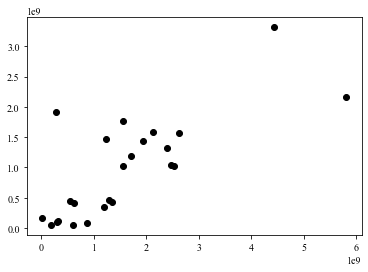

In [23]:
plt.plot(share_global['q_canal'], share_global['capacity'], 'ko')
print(np.corrcoef(share_global['q_canal'], share_global['capacity']))
#stats.spearmanr(share_global['q_canal'], share_global['capacity']).statistic

In [24]:
chokepoint_global

,canal,v,q,v_sea_predict,q_sea_predict,q_canal,v_canal,v_share_mar_trade,v_share_trade,q_share_mar_trade,q_share_trade
0,Bab el-Mandeb Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,2.524994e+09,3.717030e+12,0.165057,0.085267,0.131261,0.101525
1,Bohai Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,1.561478e+09,1.153273e+12,0.051212,0.026456,0.081173,0.062784
2,Bosporus Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,1.289923e+09,1.102138e+12,0.048941,0.025283,0.067056,0.051865
3,Cape of Good Hope,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,1.236319e+09,7.721648e+11,0.034288,0.017713,0.064270,0.049710
4,Dover Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,1.936184e+09,3.672382e+12,0.163074,0.084243,0.100652,0.077850
5,Gibraltar Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,2.628754e+09,4.071292e+12,0.180788,0.093394,0.136655,0.105697
6,Korea Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,2.385339e+09,2.384826e+12,0.105900,0.054707,0.124001,0.095910
7,Lombok Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,1.562509e+09,2.857085e+11,0.012687,0.006554,0.081227,0.062825
8,Luzon Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,2.719324e+08,5.876385e+11,0.026094,0.013480,0.014136,0.010934
9,Magellan Strait,4.359277e+13,2.487067e+10,2.251969e+13,1.923644e+10,1.798996e+08,1.378480e+11,0.006121,0.003162,0.009352,0.007233


In [25]:
chokepoint_global['v_share_mar_trade'].sum()

1.7674682046580936

In [26]:
chokepoint_global['q_share_mar_trade'].sum()

1.9709141700638413

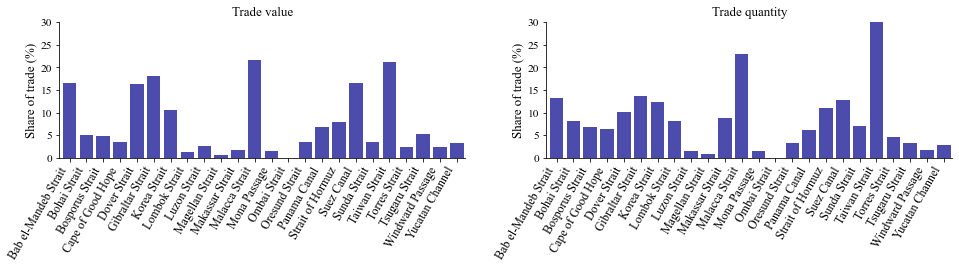

In [27]:
fig,ax = plt.subplots(figsize = (16,2.5))
ax1 = plt.subplot(1,2,1)
plt.bar(chokepoint_global['canal'], chokepoint_global['v_share_mar_trade']*100, color = 'darkblue', alpha = 0.7, label = 'Maritime trade')
plt.xticks(chokepoint_global['canal'], rotation = 60, ha='right',fontsize = 12);plt.ylabel('Share of trade (%)', fontsize = 13)
plt.ylim(0,30);plt.yticks([0, 5, 10, 15, 20, 25, 30],fontsize = 11.5);plt.title('Trade value', fontsize = 13)
plt.xlim(-0.6,23.5)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

ax2 = plt.subplot(1,2,2)
plt.bar(chokepoint_global['canal'], chokepoint_global['q_share_mar_trade']*100, color = 'darkblue', alpha = 0.7)

plt.xticks(chokepoint_global['canal'], rotation = 60, ha='right',fontsize = 12);
plt.xlim(-0.6,23.5)
plt.ylabel('Share of trade (%)', fontsize = 13)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.ylim(0,30);plt.yticks(fontsize = 11.5);plt.title('Trade quantity', fontsize = 13)

plt.savefig('Figures/Share_trade_chokepoints.png',dpi = 500, bbox_inches = 'tight', transparent = True)

In [28]:
### dominant canal ###
country_dominant_canal = trade_iso3_risk.sort_values(by = 'v_share', ascending = False).drop_duplicates(subset = 'iso3')

### number of chokepoint dependencies ###
chokepoint_25 = trade_iso3_risk[trade_iso3_risk['v_share_mar']>0.25].groupby(['iso3'])['canal'].count().reset_index().rename(columns = {'canal':'num_chokepoint_25'})
chokepoint_10 = trade_iso3_risk[trade_iso3_risk['v_share_mar']>0.1].groupby(['iso3'])['canal'].count().reset_index().rename(columns = {'canal':'num_chokepoint_10'})
chokepoint_5 = trade_iso3_risk[trade_iso3_risk['v_share_mar']>0.05].groupby(['iso3'])['canal'].count().reset_index().rename(columns = {'canal':'num_chokepoint_5'})

### 
country_dominant_canal = country_dominant_canal.merge(pd.concat([chokepoint_5.set_index('iso3'), chokepoint_10.set_index('iso3'),chokepoint_25.set_index('iso3')], axis = 1).replace(np.nan, 0).reset_index(), how = 'left', on = 'iso3').replace(np.nan, 0)

### colors ##
color_list = ['sienna','forestgreen','darkblue','purple','goldenrod','black',
              'darkorange','darkred','violet','olive','teal','peru',
             'cornflowerblue','lime','deeppink','yellow','aqua','silver',
             'grey','wheat','turquoise','deepskyblue','indigo','pink']
df_color = pd.DataFrame({'canal':cp['canal'].unique()[0:len(color_list)],'color':color_list})
color_dict = df_color.sort_values(by = 'canal').set_index('canal').to_dict()['color']

#country_dominant_canal = country_dominant_canal.merge(df_color, on = 'canal')
GADM_plot = GADM.merge(country_dominant_canal, on = ['iso3']).merge(df_color, on = 'canal')

In [29]:
print(len(country_dominant_canal['canal'].unique()))
print(len(df_color))

19
24


In [30]:
run = 'no'
if run == 'yes':
    fig,ax = plt.subplots(figsize = (12,6))
    GADM_plot.to_crs(eckert_IV).plot(ax=ax,color=GADM_plot['color'], legend=True, legend_kwds={'loc': 'lower center','ncol':4,'bbox_to_anchor':[0.5, -0.3],'frameon':False})

    leg = ax.get_legend()
    #leg.set_bbox_to_anchor((0.5, -0.25, 0.2, 0.2))

    from matplotlib.lines import Line2D
    custom_points = [Line2D([0], [0], marker="o", linestyle="none", markersize=10, color=color) for color in color_dict.values()]
    leg_points = ax.legend(custom_points, color_dict.keys())
    ax.add_artist(leg_points)
    plt.axis('off');

    plt.savefig('Figures/Dominant_chokepoint.png', dpi = 600, bbox_inches = 'tight')

In [31]:
run = 'no'
if run == 'yes':
    for metric in ['num_chokepoint_5','num_chokepoint_10','num_chokepoint_25']:
        size = (8,5)
        fig,ax = plt.subplots(figsize = size)
        norm = colors.Normalize(vmin=0, vmax=15)
        cbar = plt.cm.ScalarMappable(norm=norm, cmap='YlOrRd')

        GADM[(~GADM['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
        GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap='YlOrRd',ax = ax,vmin = 0, vmax = 15,legend = False);

        ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.05,ticks=[0,3,6,9,12, 15],orientation='horizontal')
        ax_cbar.ax.set_xticklabels(['0','3','6','9','12','15'],fontsize = 13)
        ax_cbar.set_label('Number of chokepoints (#)',fontsize = 13)

        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False); ax.spines['left'].set_visible(False)
        ax.get_xaxis().set_ticks([]);ax.get_yaxis().set_ticks([]);
        plt.savefig('Figures/global_'+metric+'.png', dpi = 500, bbox_inches = 'tight')

In [32]:
#cat_min = [0, 1e6, 1e7, 1e8, 1e9, 1e10]
#cat_max = [1e6, 1e7, 1e8, 1e9, 1e10, 1e16]
cat_median = [0, 1e6, 1.01e6,1e7,1.01e7, 1e8,1.01e8, 1e9, 1.01e9,1e10, 1.01e10]
cat_color = ['lightblue','lightblue','darkblue','darkblue','gold','gold','orange','orange','red','red','black']

df_cat = pd.DataFrame({'val':cat_median,'color':cat_color})

## 
df_plot = chokepoint_trade_risk.set_index(['canal','reroute_days','reroute_km']).stack().reset_index().rename(columns = {'level_3':'cat',0:'val'}).sort_values(by = 'val')
df_plot = pd.merge_asof(df_plot, df_cat, on = 'val', direction = 'nearest')

In [33]:
### trade at risk for rerouting alternatives ##
plot_noreroute = df_plot[df_plot['reroute_km']==0]
plot_shortreroute = df_plot[(df_plot['reroute_km']>0)&(df_plot['reroute_km']<5000)]
plot_longreroute = df_plot[df_plot['reroute_km']>5000]

In [34]:
plot_shortreroute[plot_shortreroute['cat']=='trade_at_risk_v']

,canal,reroute_days,reroute_km,cat,val,color
125,Cape of Good Hope,1.407658,1000,trade_at_risk_v,8.462080e+05,lightblue
140,Makassar Strait,5.912162,4200,trade_at_risk_v,1.165637e+07,gold
145,Ombai Strait,1.689189,1200,trade_at_risk_v,3.233275e+07,gold
159,Lombok Strait,3.800676,2700,trade_at_risk_v,1.196125e+08,orange
165,Sunda Strait,3.941441,2800,trade_at_risk_v,2.330524e+08,orange
172,Dover Strait,3.519144,2500,trade_at_risk_v,4.987541e+08,orange
175,Mona Passage,2.533784,1800,trade_at_risk_v,6.149690e+08,orange
184,Yucatan Channel,3.941441,2800,trade_at_risk_v,9.939786e+08,orange
186,Tsugaru Strait,0.703829,500,trade_at_risk_v,1.169857e+09,red
197,Windward Passage,2.533784,1800,trade_at_risk_v,3.261428e+09,red


In [35]:
plot_shortreroute[plot_shortreroute['cat']!='trade_at_risk_v'].tail(10)

,canal,reroute_days,reroute_km,cat,val,color
179,Yucatan Channel,3.941441,2800,trade_at_risk_TC_v,7.779742e+08,orange
185,Tsugaru Strait,0.703829,500,trade_at_risk_TC_v,1.161785e+09,red
188,Korea Strait,1.407658,1000,trade_at_risk_geopolitical_v,1.429262e+09,red
193,Windward Passage,2.533784,1800,trade_at_risk_geopolitical_v,2.588498e+09,red
196,Malacca Strait,2.111486,1500,trade_at_risk_geopolitical_v,3.077204e+09,red
200,Luzon Strait,5.630631,4000,trade_at_risk_TC_v,4.846166e+09,red
203,Korea Strait,1.407658,1000,trade_at_risk_TC_v,6.814069e+09,red
205,Malacca Strait,2.111486,1500,trade_at_risk_piracy_v,9.699520e+09,red
208,Taiwan Strait,1.407658,1000,trade_at_risk_geopolitical_v,1.316587e+10,black
210,Taiwan Strait,1.407658,1000,trade_at_risk_TC_v,2.347902e+10,black


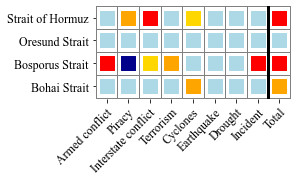

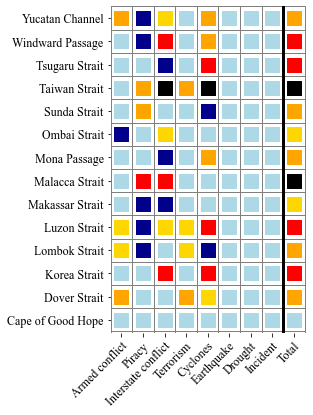

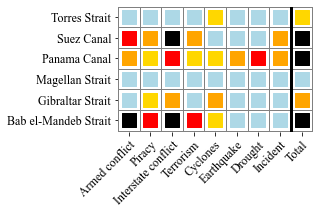

In [36]:
cat_list  = list(df_plot.cat.unique())
cat_name = ['Armed conflict','Piracy','Interstate conflict','Terrorism','Cyclones','Earthquake','Drought','Incident','Total']

### 1.5, 6,2

for plot, size, name in zip([plot_noreroute, plot_shortreroute, plot_longreroute], [1.7,6,2.3], ['no','short','long']):
    canal_list = np.sort(plot.canal.unique())
    fig,ax = plt.subplots(figsize = (3.5,size))

    for canal, i in zip(canal_list, range(0, len(canal_list))):
        plt.axhline(y = i-0.5, color = 'grey',lw = 1)
        for j in range(0, len(cat_list)):
            val = plot[(plot['canal']==canal)&(plot['cat']==cat_list[j])]
            ax.scatter(j, i, s = 200, marker = 's', color = val['color'].iloc[0])
    plt.axhline(y = len(canal_list)-0.5, color = 'grey',lw = 1)

    for j in range(0,len(cat_list)):
        plt.axvline(x = j-0.5, color = 'grey',lw = 1)
    plt.axvline(x = j+0.5, color = 'grey', lw = 1)
    plt.axvline(x = j-0.5, color = 'k', lw = 3)

    plt.box(False)
    plt.yticks(range(0, len(canal_list)), canal_list, fontsize = 12);
    plt.xticks(range(0, len(cat_name)), cat_name, rotation = 45, rotation_mode='anchor', verticalalignment = 'top', horizontalalignment = 'right', fontsize = 12);
    plt.xlim(-0.5, 8.55)
    plt.ylim(-0.55, len(canal_list)-0.5)
    plt.savefig('Figures/trade_at_risk_'+name+'.png', dpi = 500,bbox_inches = 'tight')

191.4682298859594


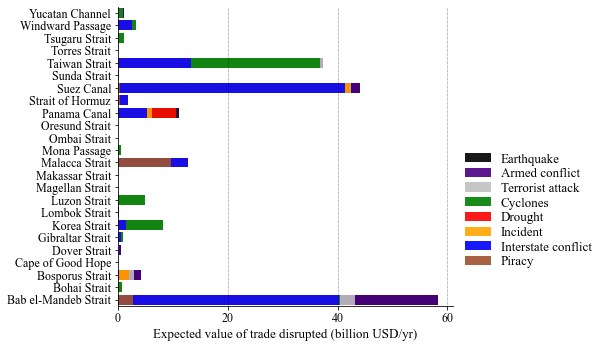

In [37]:
### trade at-risk from different drivers ###
print(chokepoint_trade_risk['trade_at_risk_v'].sum()/1e9)
###
fig,ax = plt.subplots(figsize = (6,5.5))
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v','trade_at_risk_drought_v','trade_at_risk_TC_v','trade_at_risk_terrorist_v','trade_at_risk_conflict_v','trade_at_risk_EQ_v']].sum(axis = 1)/1e9, color = 'black', alpha = 0.9, label = 'Earthquake')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v','trade_at_risk_drought_v','trade_at_risk_TC_v','trade_at_risk_terrorist_v','trade_at_risk_conflict_v']].sum(axis = 1)/1e9, color = 'indigo', alpha = 0.9, label = 'Armed conflict')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v','trade_at_risk_drought_v','trade_at_risk_TC_v','trade_at_risk_terrorist_v']].sum(axis = 1)/1e9, color = 'silver', alpha = 0.9, label = 'Terrorist attack')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v','trade_at_risk_drought_v','trade_at_risk_TC_v']].sum(axis = 1)/1e9, color = 'green', alpha = 0.9, label = 'Cyclones')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v','trade_at_risk_drought_v']].sum(axis = 1)/1e9, color = 'red', alpha = 0.9, label = 'Drought')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v','trade_at_risk_blockage_v']].sum(axis = 1)/1e9, color = 'orange', alpha = 0.9, label = 'Incident')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk[['trade_at_risk_piracy_v','trade_at_risk_geopolitical_v']].sum(axis = 1)/1e9, color = 'blue', alpha = 0.9, label = 'Interstate conflict')
plt.barh(chokepoint_trade_risk['canal'], chokepoint_trade_risk['trade_at_risk_piracy_v']/1e9, color = 'sienna', alpha = 0.9, label = 'Piracy')

plt.legend(bbox_to_anchor = (1.0, 0.55), columnspacing=0.5, labelspacing = 0.2, frameon = False, ncol = 1, fontsize = 13)
plt.yticks(chokepoint_trade_risk['canal'], rotation = 0, fontsize = 12);plt.xlabel('Expected value of trade disrupted (billion USD/yr)', fontsize = 13)
#ax.set_xscale('log')
plt.xlim(0,61);plt.xticks([0,20,40,60],fontsize = 12);
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.axvline(x =20, color = 'k', lw = 0.5, linestyle = ':')
plt.axvline(x =40, color = 'k', lw = 0.5, linestyle = ':')
plt.axvline(x =60, color = 'k', lw = 0.5, linestyle = ':')
plt.ylim(-0.5,23.5)
plt.savefig('Figures/trade_at_risk_chokepoints.png', dpi = 600, bbox_inches = 'tight')

<AxesSubplot:xlabel='canal'>

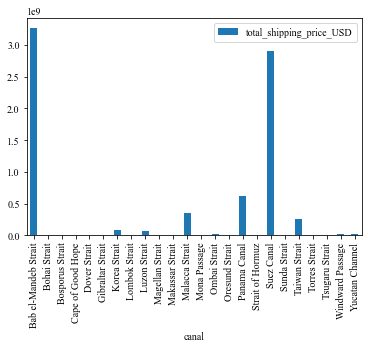

In [38]:
chokepoint_econ[['canal','total_shipping_price_USD']].set_index('canal').plot.bar()

In [39]:
chokepoint_econ[['canal','total_shipping_price_USD']].to_csv('shipping_cost.csv', index = False)

In [40]:
chokepoint_econ['total_shipping_price_USD'].sum()/1e9

7.637232569859461

In [41]:
econ_small = chokepoint_econ[chokepoint_econ['total_loss_USD']<1e7]
econ_medium = chokepoint_econ[(chokepoint_econ['total_loss_USD']>1e7)&(chokepoint_econ['total_loss_USD']<1e8)]
econ_large = chokepoint_econ[(chokepoint_econ['total_loss_USD']>1e8)]

print(len(econ_small), len(econ_medium), len(econ_large))

9 6 9


In [42]:
econ_large[['canal','total_loss_USD']].sort_values('total_loss_USD')

,canal,total_loss_USD
8,Luzon Strait,1.223903e+08
6,Korea Strait,1.288725e+08
2,Bosporus Strait,1.734996e+08
16,Strait of Hormuz,4.603702e+08
15,Panama Canal,5.628975e+08
19,Taiwan Strait,8.839709e+08
11,Malacca Strait,1.066700e+09
17,Suez Canal,2.071693e+09
0,Bab el-Mandeb Strait,4.159104e+09


In [43]:
econ_large[['canal','total_loss_USD']].sort_values('total_loss_USD').tail(3)['total_loss_USD'].sum()/10.7e9

0.6820090899747011

9.858750714811151
9.629498243598247


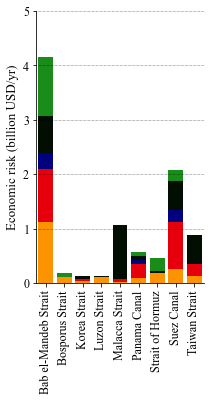

In [44]:
fig,ax = plt.subplots(figsize = (3,5))
print(chokepoint_econ['total_loss_USD'].sum()/1e9)
print(econ_large['total_loss_USD'].sum()/1e9)
plt.bar(econ_large['canal'], econ_large[['total_loss_USD']].sum(axis = 1)/1e9, color = 'green', alpha = 0.9, label = 'Lost trade')
plt.bar(econ_large['canal'], econ_large[['total_delay_USD','total_rerouting_USD','total_revenue_USD','total_war_premium_USD']].sum(axis = 1)/1e9, color = 'black', alpha = 0.9, label = 'Insurance premium')
plt.bar(econ_large['canal'], econ_large[['total_delay_USD','total_rerouting_USD','total_revenue_USD']].sum(axis = 1)/1e9, color = 'darkblue', alpha = 0.9, label = 'Toll revenue')
plt.bar(econ_large['canal'], econ_large[['total_delay_USD','total_rerouting_USD']].sum(axis = 1)/1e9, color = 'red', alpha = 0.9, label = 'Rerouting')
plt.bar(econ_large['canal'], econ_large[['total_delay_USD']].sum(axis = 1)/1e9, color = 'orange', alpha = 0.9, label = 'Delays')

#plt.legend(bbox_to_anchor = (1.0, 0.45),columnspacing=0.5, labelspacing = 0.2,frameon = False, ncol = 1, fontsize = 13)
plt.xticks(econ_large['canal'], rotation = 90, fontsize = 12);plt.ylabel('Economic risk (billion USD/yr)', fontsize = 13)
plt.ylim(0,5);plt.yticks([0,1,2, 3,4,5], fontsize = 12);
plt.axhline(y=1, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =2, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =3, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =4, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =5, color = 'k', lw = 0.5, linestyle = ':')
#plt.axvline(x =25, color = 'k', lw = 0.5, linestyle = ':')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.xlim(-0.5,8.5)
plt.savefig('Figures/economic_risk_chokepoints_high.png', dpi = 600, bbox_inches = 'tight')

0.2173098599044154


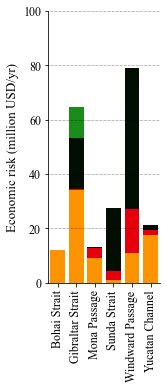

In [72]:
fig,ax = plt.subplots(figsize = (2,5))
print(econ_medium['total_loss_USD'].sum()/1e9)
plt.bar(econ_medium['canal'], econ_medium[['total_loss_USD']].sum(axis = 1)/1e7, color = 'green', alpha = 0.9, label = 'Lost trade')
plt.bar(econ_medium['canal'], econ_medium[['total_delay_USD','total_rerouting_USD','total_revenue_USD','total_war_premium_USD']].sum(axis = 1)/1e7, color = 'black', alpha = 0.9, label = 'Insurance premium')
plt.bar(econ_medium['canal'], econ_medium[['total_delay_USD','total_rerouting_USD','total_revenue_USD']].sum(axis = 1)/1e7, color = 'darkblue', alpha = 0.9, label = 'Toll revenue')
plt.bar(econ_medium['canal'], econ_medium[['total_delay_USD','total_rerouting_USD']].sum(axis = 1)/1e7, color = 'red', alpha = 0.9, label = 'Rerouting')
plt.bar(econ_medium['canal'], econ_medium[['total_delay_USD']].sum(axis = 1)/1e7, color = 'orange', alpha = 0.9, label = 'Delays')

#plt.legend(bbox_to_anchor = (1.0, 0.45),columnspacing=0.5, labelspacing = 0.2,frameon = False, ncol = 1, fontsize = 13)
plt.xticks(econ_medium['canal'], rotation = 90, fontsize = 12);plt.ylabel('Economic risk (million USD/yr)', fontsize = 13)
plt.ylim(0,10);plt.yticks([0,2,4, 6,8,10],['0','20','40','60','80','100'], fontsize = 12);
plt.axhline(y =2, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =4, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =6, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =8, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =10, color = 'k', lw = 0.5, linestyle = ':')
#plt.axvline(x =25, color = 'k', lw = 0.5, linestyle = ':')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.xlim(-0.5,5.5)
plt.savefig('Figures/economic_risk_chokepoints_medium.png', dpi = 600, bbox_inches = 'tight')

0.011942611308490551


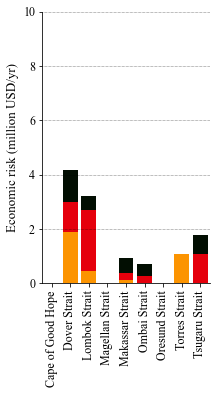

In [46]:
fig,ax = plt.subplots(figsize = (3,5))
print(econ_small['total_loss_USD'].sum()/1e9)
plt.bar(econ_small['canal'], econ_small[['total_loss_USD']].sum(axis = 1)/1e6, color = 'green', alpha = 0.9, label = 'Lost trade')
plt.bar(econ_small['canal'], econ_small[['total_delay_USD','total_rerouting_USD','total_revenue_USD','total_war_premium_USD']].sum(axis = 1)/1e6, color = 'black', alpha = 0.9, label = 'Insurance premium')
plt.bar(econ_small['canal'], econ_small[['total_delay_USD','total_rerouting_USD','total_revenue_USD']].sum(axis = 1)/1e6, color = 'darkblue', alpha = 0.9, label = 'Toll revenue')
plt.bar(econ_small['canal'], econ_small[['total_delay_USD','total_rerouting_USD']].sum(axis = 1)/1e6, color = 'red', alpha = 0.9, label = 'Rerouting')
plt.bar(econ_small['canal'], econ_small[['total_delay_USD']].sum(axis = 1)/1e6, color = 'orange', alpha = 0.9, label = 'Delays')

#plt.legend(bbox_to_anchor = (1.0, 0.45),columnspacing=0.5, labelspacing = 0.2,frameon = False, ncol = 1, fontsize = 13)
plt.xticks(econ_small['canal'], rotation = 90, fontsize = 12);plt.ylabel('Economic risk (million USD/yr)', fontsize = 13)
plt.ylim(0,10);plt.yticks([0,2,4, 6,8,10],['0','2','4','6','8','10'], fontsize = 12);
plt.axhline(y =2, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =4, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =6, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =8, color = 'k', lw = 0.5, linestyle = ':')
plt.axhline(y =10, color = 'k', lw = 0.5, linestyle = ':')
#plt.axvline(x =25, color = 'k', lw = 0.5, linestyle = ':')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.xlim(-0.5,8.5)
plt.savefig('Figures/economic_risk_chokepoints_low.png', dpi = 600, bbox_inches = 'tight')

In [47]:
country_loss = econ_iso3_risk.groupby(['iso3'])[['total_loss_USD','trade_at_risk_v']].sum().reset_index().merge(trade_iso3_risk[['iso3','v','v_sea_predict']].drop_duplicates(), on = 'iso3')
country_loss['loss_share_mar_trade'] = country_loss['total_loss_USD']/country_loss['v_sea_predict']
country_loss['loss_share_trade'] = country_loss['total_loss_USD']/country_loss['v']
country_loss['trade_risk_share_trade'] = country_loss['trade_at_risk_v']/country_loss['v']
country_loss['trade_risk_share_mar_trade'] = country_loss['trade_at_risk_v']/country_loss['v_sea_predict']

In [48]:
## diferent groups ###
country_loss_noreroute = econ_iso3_risk[econ_iso3_risk['canal'].isin(plot_noreroute['canal'].unique())].groupby(['iso3'])[['total_loss_USD','trade_at_risk_v']].sum().reset_index().merge(trade_iso3_risk[['iso3','v','v_sea_predict']].drop_duplicates(), on = 'iso3')
country_loss_noreroute['trade_risk_share_mar_trade'] = country_loss_noreroute['trade_at_risk_v']/country_loss_noreroute['v_sea_predict']

country_loss_shortreroute = econ_iso3_risk[econ_iso3_risk['canal'].isin(plot_shortreroute['canal'].unique())].groupby(['iso3'])[['total_loss_USD','trade_at_risk_v']].sum().reset_index().merge(trade_iso3_risk[['iso3','v','v_sea_predict']].drop_duplicates(), on = 'iso3')
country_loss_shortreroute['trade_risk_share_mar_trade'] = country_loss_shortreroute['trade_at_risk_v']/country_loss_shortreroute['v_sea_predict']

country_loss_longreroute = econ_iso3_risk[econ_iso3_risk['canal'].isin(plot_longreroute['canal'].unique())].groupby(['iso3'])[['total_loss_USD','trade_at_risk_v']].sum().reset_index().merge(trade_iso3_risk[['iso3','v','v_sea_predict']].drop_duplicates(), on = 'iso3')
country_loss_longreroute['trade_risk_share_mar_trade'] = country_loss_longreroute['trade_at_risk_v']/country_loss_longreroute['v_sea_predict']


In [49]:
country_loss['trade_risk_share_trade'].describe()

count    198.000000
mean       0.009699
std        0.007260
min        0.000314
25%        0.004431
50%        0.007378
75%        0.012121
max        0.035641
Name: trade_risk_share_trade, dtype: float64

In [50]:
country_loss['trade_risk_share_mar_trade'].describe()

count    198.000000
mean       0.015614
std        0.009502
min        0.000648
25%        0.008392
50%        0.013025
75%        0.020519
max        0.044745
Name: trade_risk_share_mar_trade, dtype: float64

In [51]:
country_loss['loss_share_mar_trade'].describe()

count    198.000000
mean       0.000452
std        0.000560
min        0.000017
25%        0.000173
50%        0.000293
75%        0.000495
max        0.005577
Name: loss_share_mar_trade, dtype: float64

In [52]:
country_loss['loss_share_trade'].describe()

count    198.000000
mean       0.000289
std        0.000462
min        0.000008
25%        0.000090
50%        0.000166
75%        0.000313
max        0.004945
Name: loss_share_trade, dtype: float64

In [53]:
len(country_loss[country_loss['loss_share_mar_trade']>0.001])

19

In [54]:
country_loss.sort_values(by = ['loss_share_mar_trade'])

,iso3,total_loss_USD,trade_at_risk_v,v,v_sea_predict,loss_share_mar_trade,loss_share_trade,trade_risk_share_trade,trade_risk_share_mar_trade
167,SXM,5.144948e+03,1.990827e+05,6.339707e+08,3.073203e+08,0.000017,0.000008,0.000314,0.000648
70,GNQ,1.188615e+05,9.233770e+07,7.022732e+09,6.854989e+09,0.000017,0.000017,0.013148,0.013470
180,TUV,1.870442e+03,2.705028e+05,8.899002e+07,8.039203e+07,0.000023,0.000021,0.003040,0.003365
141,PNG,5.885102e+05,1.552377e+08,1.709627e+10,1.477005e+10,0.000040,0.000034,0.009080,0.010510
2,AGO,3.102670e+06,4.726092e+08,6.378262e+10,5.729603e+10,0.000054,0.000049,0.007410,0.008249
...,...,...,...,...,...,...,...,...,...
93,KGZ,3.915297e+06,5.774990e+07,1.983238e+10,2.230169e+09,0.001756,0.000197,0.002912,0.025895
194,YEM,1.451585e+07,2.207500e+08,1.151507e+10,6.980423e+09,0.002080,0.001261,0.019171,0.031624
47,DJI,1.549847e+07,2.505703e+08,7.982554e+09,7.003926e+09,0.002213,0.001942,0.031390,0.035776
137,PAN,8.252082e+07,2.750408e+08,3.125670e+10,2.550007e+10,0.003236,0.002640,0.008799,0.010786


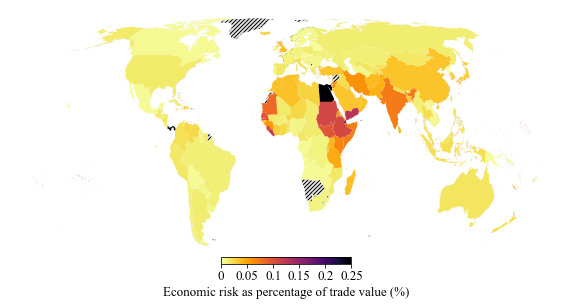

In [55]:
metric = 'loss_share_trade'

size = (10,6)
fig,ax = plt.subplots(figsize = size)
GADM_plot = GADM.merge(country_loss, on = ['iso3'])

norm = colors.Normalize(vmin=0, vmax=0.0025)
cbar = plt.cm.ScalarMappable(norm=norm, cmap='inferno_r')

world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap='inferno_r',ax = ax,vmin=0, vmax=0.0025,legend = False);


ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.0,ticks=[0,0.0005,0.001,0.0015,0.002,0.0025],orientation='horizontal')
ax_cbar.ax.set_xticklabels(['0','0.05','0.1','0.15','0.2','0.25'],fontsize = 13)
ax_cbar.set_label('Economic risk as percentage of trade value (%)',fontsize = 13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_xaxis().set_ticks([]);
ax.get_yaxis().set_ticks([]);

plt.savefig('Figures/Economic_risk_all_trade.png', dpi = 600, bbox_inches = 'tight')


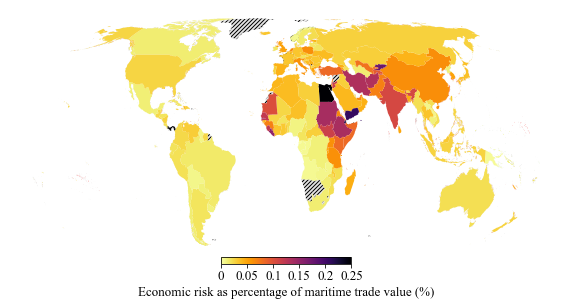

In [56]:
metric = 'loss_share_mar_trade'

size = (10,6)
fig,ax = plt.subplots(figsize = size)
GADM_plot = GADM.merge(country_loss, on = ['iso3'])

norm = colors.Normalize(vmin=0, vmax=0.0025)
cbar = plt.cm.ScalarMappable(norm=norm, cmap='inferno_r')

world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap='inferno_r',ax = ax,vmin=0, vmax=0.0025,legend = False);


ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.00,ticks=[0,0.0005,0.001,0.0015,0.002,0.0025],orientation='horizontal')
ax_cbar.ax.set_xticklabels(['0','0.05','0.1','0.15','0.2','0.25'],fontsize = 13)
ax_cbar.set_label('Economic risk as percentage of maritime trade value (%)',fontsize = 13)

ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False); ax.spines['left'].set_visible(False)
ax.get_xaxis().set_ticks([]);ax.get_yaxis().set_ticks([]);

plt.savefig('Figures/Economic_risk_maritime_trade.png', dpi = 600, bbox_inches = 'tight')


In [57]:
country_loss.sort_values(by = 'loss_share_trade').tail(10)

,iso3,total_loss_USD,trade_at_risk_v,v,v_sea_predict,loss_share_mar_trade,loss_share_trade,trade_risk_share_trade,trade_risk_share_mar_trade
161,SSD,8.662130e+05,2.374658e+07,8.881232e+08,7.616814e+08,0.001137,0.000975,0.026738,0.031177
157,SLE,2.661375e+06,7.851210e+07,2.542144e+09,2.202122e+09,0.001209,0.001047,0.030884,0.035653
57,ETH,1.757198e+07,4.334203e+08,1.640069e+10,1.281058e+10,0.001372,0.001071,0.026427,0.033833
153,SDN,1.403471e+07,3.272299e+08,1.293940e+10,1.016118e+10,0.001381,0.001085,0.025289,0.032204
100,LBR,4.187141e+06,8.180254e+07,3.423900e+09,2.745673e+09,0.001525,0.001223,0.023892,0.029793
194,YEM,1.451585e+07,2.207500e+08,1.151507e+10,6.980423e+09,0.002080,0.001261,0.019171,0.031624
68,GMB,1.944788e+06,4.011067e+07,1.499917e+09,1.244568e+09,0.001563,0.001297,0.026742,0.032229
47,DJI,1.549847e+07,2.505703e+08,7.982554e+09,7.003926e+09,0.002213,0.001942,0.031390,0.035776
137,PAN,8.252082e+07,2.750408e+08,3.125670e+10,2.550007e+10,0.003236,0.002640,0.008799,0.010786
53,EGY,6.345934e+08,2.990780e+09,1.283198e+11,1.137807e+11,0.005577,0.004945,0.023307,0.026285


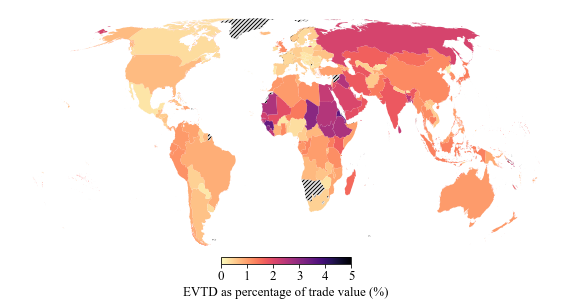

In [58]:
metric = 'trade_risk_share_trade'
colorbar = 'magma_r'

size = (10,6)
fig,ax = plt.subplots(figsize = size)
GADM_plot = GADM.merge(country_loss, on = ['iso3'])
norm = colors.Normalize(vmin=0, vmax=0.05)
cbar = plt.cm.ScalarMappable(norm=norm, cmap=colorbar)

world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap=colorbar,ax = ax,vmin = 0, vmax = 0.05,legend = False);


ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.0,ticks=[0,0.01,0.02,0.03,0.04, 0.05],orientation='horizontal')
ax_cbar.ax.set_xticklabels(['0','1','2','3','4','5'],fontsize = 13)
ax_cbar.set_label('EVTD as percentage of trade value (%)',fontsize = 13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_xaxis().set_ticks([]);
ax.get_yaxis().set_ticks([]);

plt.savefig('Figures/Trade_at_risk_all_trade.png', dpi = 600, bbox_inches = 'tight')


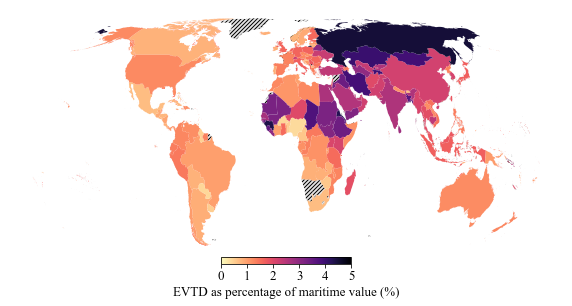

In [59]:
metric = 'trade_risk_share_mar_trade'
colorbar = 'magma_r'

size = (10,6)
fig,ax = plt.subplots(figsize = size)
GADM_plot = GADM.merge(country_loss, on = ['iso3'])
norm = colors.Normalize(vmin=0, vmax=0.05)
cbar = plt.cm.ScalarMappable(norm=norm, cmap=colorbar)

world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap=colorbar,ax = ax,vmin = 0, vmax = 0.05,legend = False);


ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.0,ticks=[0,0.01,0.02,0.03,0.04, 0.05],orientation='horizontal')
ax_cbar.ax.set_xticklabels(['0','1','2','3','4','5'],fontsize = 13)
ax_cbar.set_label('EVTD as percentage of maritime value (%)',fontsize = 13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_xaxis().set_ticks([]);
ax.get_yaxis().set_ticks([]);

plt.savefig('Figures/Trade_at_risk_maritime_trade.png', dpi = 600, bbox_inches = 'tight')


In [60]:
country_loss_longreroute.sort_values(by = 'trade_risk_share_mar_trade').tail(10)

,iso3,total_loss_USD,trade_at_risk_v,v,v_sea_predict,trade_risk_share_mar_trade
157,SLE,2.378875e+06,6.302929e+07,2.542144e+09,2.202122e+09,0.028622
47,DJI,1.275447e+07,2.054788e+08,7.982554e+09,7.003926e+09,0.029338
83,IRN,2.215045e+07,6.401225e+08,4.778557e+10,2.152168e+10,0.029743
16,BGD,2.162285e+07,2.569520e+09,1.307998e+11,8.625829e+10,0.029789
170,TCD,4.041404e+05,9.500709e+07,3.932811e+09,3.178185e+09,0.029894
54,ERI,5.108027e+05,2.810290e+07,1.122418e+09,9.386682e+08,0.029939
114,MLI,1.484739e+06,2.096848e+08,1.142464e+10,6.925413e+09,0.030278
150,RUS,6.103240e+07,8.657706e+09,6.047430e+11,2.856846e+11,0.030305
69,GNB,1.528348e+05,1.262984e+07,5.225046e+08,4.157590e+08,0.030378
67,GIN,7.738847e+06,4.098502e+08,1.545918e+10,1.243177e+10,0.032968


In [61]:
country_loss_shortreroute.sort_values(by = 'trade_risk_share_mar_trade').tail(16)

,iso3,total_loss_USD,trade_at_risk_v,v,v_sea_predict,trade_risk_share_mar_trade
93,KGZ,6.410173e+05,2.221894e+07,1.983238e+10,2.230169e+09,0.009963
91,KAZ,3.141502e+06,6.030741e+08,1.447260e+11,6.014784e+10,0.010027
173,TJK,2.202950e+05,1.429477e+07,6.203035e+09,1.388228e+09,0.010297
61,FSM,9.925689e+03,2.592932e+06,2.787347e+08,2.508802e+08,0.010335
152,SAU,2.421761e+07,3.890842e+09,4.622571e+11,3.764290e+11,0.010336
150,RUS,1.425029e+07,3.021469e+09,6.047430e+11,2.856846e+11,0.010576
62,GAB,1.127209e+05,9.937558e+07,9.782057e+09,9.267647e+09,0.010723
181,TWN,7.445231e+07,5.963765e+09,9.020977e+11,5.504068e+11,0.010835
32,CHN,6.714011e+08,3.475210e+10,5.670765e+12,3.205067e+12,0.010843
135,OMN,3.207982e+06,8.909891e+08,9.900662e+10,8.036204e+10,0.011087


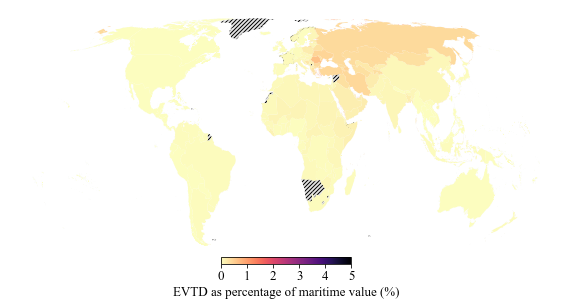

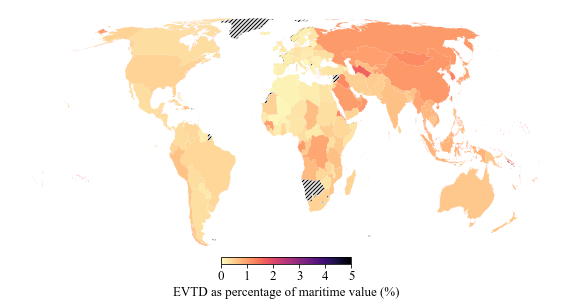

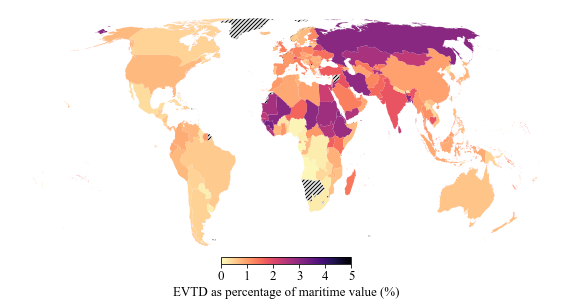

In [62]:
metric = 'trade_risk_share_mar_trade'
colorbar = 'magma_r'
size = (10,6)

for df, name in zip([country_loss_noreroute, country_loss_shortreroute, country_loss_longreroute], ['no','short','long']):
    fig,ax = plt.subplots(figsize = size)
    GADM_plot = GADM.merge(df, on = ['iso3'])
    norm = colors.Normalize(vmin=0, vmax=0.05)
    cbar = plt.cm.ScalarMappable(norm=norm, cmap=colorbar)

    world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
    GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap=colorbar,ax = ax,vmin = 0, vmax = 0.05,legend = False);


    ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.0,ticks=[0,0.01,0.02,0.03,0.04, 0.05],orientation='horizontal')
    ax_cbar.ax.set_xticklabels(['0','1','2','3','4','5'],fontsize = 13)
    ax_cbar.set_label('EVTD as percentage of maritime value (%)',fontsize = 13)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_xaxis().set_ticks([]);
    ax.get_yaxis().set_ticks([]);

    plt.savefig('Figures/Trade_at_risk_maritime_trade_'+name+'.png', dpi = 600, bbox_inches = 'tight', transparent = True)


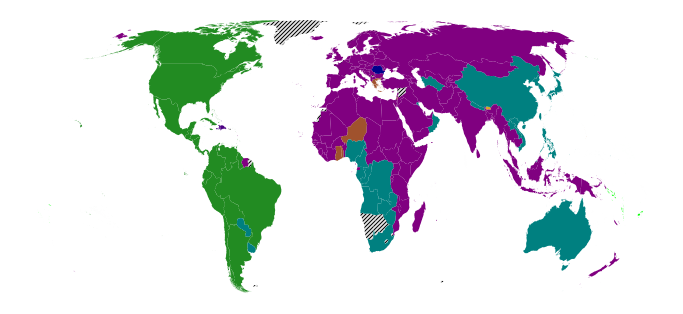

In [63]:
### dominant chokepoint trade at-risk
trade_iso3_risk['trade_risk_share_mar_trade'] = trade_iso3_risk['trade_at_risk_v']/trade_iso3_risk['v_sea_predict']

### dominant canal ###
country_dominant_canal = trade_iso3_risk.sort_values(by = 'trade_risk_share_mar_trade', ascending = False).drop_duplicates(subset = 'iso3')

GADM_plot = GADM.merge(country_dominant_canal, on = ['iso3']).merge(df_color, on = 'canal')

fig,ax = plt.subplots(figsize = (12,6))
world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
GADM_plot.to_crs(eckert_IV).plot(ax=ax, color=GADM_plot['color'], legend = True, legend_kwds={'loc': 'lower center','ncol':4,'frameon':True})
plt.axis('off');
plt.savefig('Figures/Dominant_chokepoint_trade_atrisk.png', dpi = 600, bbox_inches = 'tight')

In [64]:
country_dominant_canal.canal.value_counts()

canal
Bab el-Mandeb Strait    115
Panama Canal             33
Taiwan Strait            29
Luzon Strait              7
Suez Canal                5
Windward Passage          3
Malacca Strait            2
Bosporus Strait           1
Mona Passage              1
Korea Strait              1
Yucatan Channel           1
Name: count, dtype: int64

In [65]:
country_dominant_canal[country_dominant_canal['canal']=='Windward Passage']

,iso3,canal,q,v,q_sea_predict,v_sea_predict,q_sea_import,v_sea_import,q_sea_export,v_sea_export,...,trade_impacted_terrorist,trade_at_risk_conflict_v,trade_at_risk_conflict_q,revenue_at_risk_conflict,trade_impacted_conflict,trade_at_risk_v,trade_at_risk_q,revenue_at_risk,trade_impacted,trade_risk_share_mar_trade
1894,HTI,Windward Passage,3.444607e+06,4.482382e+09,2.750526e+06,3.546983e+09,2.651926e+06,2.426025e+09,9.860025e+04,1.120958e+09,...,6.148822e+06,NaN,NaN,NaN,6.148822e+06,1.343193e+07,11005.407338,0.0,8.901737e+07,0.003787
1222,DOM,Windward Passage,2.298236e+07,4.234642e+10,2.180850e+07,3.460994e+10,1.791163e+07,2.459668e+10,3.896871e+06,1.001326e+10,...,5.321765e+07,NaN,NaN,NaN,5.321765e+07,1.162525e+08,47537.754566,0.0,7.704395e+08,0.003359
4078,TCA,Windward Passage,3.132841e+05,3.557833e+08,3.039254e+05,2.839940e+08,3.017845e+05,2.773827e+08,2.140901e+03,6.611267e+06,...,1.113807e+05,NaN,NaN,NaN,1.113807e+05,2.433080e+05,808.926688,0.0,1.612474e+06,0.000857


In [66]:
country_dominant_canal[country_dominant_canal['canal']=='Luzon Strait']

,iso3,canal,q,v,q_sea_predict,v_sea_predict,q_sea_import,v_sea_import,q_sea_export,v_sea_export,...,trade_impacted_terrorist,trade_at_risk_conflict_v,trade_at_risk_conflict_q,revenue_at_risk_conflict,trade_impacted_conflict,trade_at_risk_v,trade_at_risk_q,revenue_at_risk,trade_impacted,trade_risk_share_mar_trade
3752,SLB,Luzon Strait,1.582826e+06,8.789884e+08,1.560845e+06,7.920532e+08,1.934029e+05,3.250548e+08,1.367442e+06,4.669984e+08,...,2.143404e+06,61240.112165,190.914514,0.0,2.143404e+06,6.622600e+06,20645.790183,0.0,1.086706e+07,0.008361
2696,MHL,Luzon Strait,3.251286e+05,8.706046e+08,3.079114e+05,7.475566e+08,2.701483e+05,6.790701e+08,3.776314e+04,6.848651e+07,...,1.665293e+06,47579.807161,19.526424,0.0,1.665293e+06,5.145354e+06,2111.617647,0.0,8.443037e+06,0.006883
4232,TON,Luzon Strait,9.325011e+04,1.973990e+08,8.829270e+04,1.636196e+08,8.339238e+04,1.575465e+08,4.900327e+03,6.073084e+06,...,2.077928e+05,5936.937248,1.811746,0.0,2.077928e+05,6.420296e+05,195.925038,0.0,1.053510e+06,0.003924
4640,WSM,Luzon Strait,1.996533e+05,3.986616e+08,1.898872e+05,3.268088e+08,1.834612e+05,3.053709e+08,6.425914e+03,2.143790e+07,...,3.992626e+05,11407.503173,4.308118,0.0,3.992626e+05,1.233625e+06,465.886488,0.0,2.024261e+06,0.003775
4616,VUT,Luzon Strait,1.878978e+05,4.634744e+08,1.795823e+05,3.934297e+08,1.045717e+05,2.187277e+08,7.501058e+04,1.747020e+08,...,3.905327e+05,11158.076005,2.991370,0.0,3.905327e+05,1.206652e+06,323.491353,0.0,1.980001e+06,0.003067
1424,FJI,Luzon Strait,2.836629e+06,3.494925e+09,2.762536e+06,2.865053e+09,1.187374e+06,1.856975e+09,1.575162e+06,1.008078e+09,...,2.416261e+06,69036.025688,52.754922,0.0,2.416261e+06,7.465662e+06,5704.998642,0.0,1.225044e+07,0.002606
3200,NRU,Luzon Strait,7.817523e+04,7.229408e+07,7.622294e+04,5.680161e+07,2.271120e+04,4.583275e+07,5.351174e+04,1.096886e+07,...,3.596966e+04,1027.704702,0.429244,0.0,3.596966e+04,1.111376e+05,46.419116,0.0,1.823662e+05,0.001957


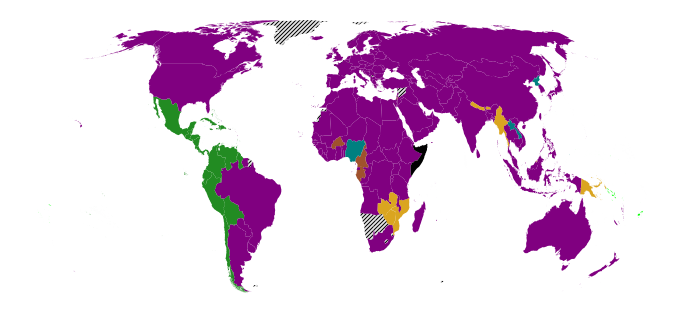

In [67]:
### dominant chokepoint trade at-risk
econ_iso3_risk['loss_share_mar_trade'] = econ_iso3_risk['total_loss_USD']/econ_iso3_risk['v_sea_predict']

### dominant canal ###
country_dominant_canal = econ_iso3_risk.sort_values(by = 'loss_share_mar_trade', ascending = False).drop_duplicates(subset = 'iso3')

GADM_plot = GADM.merge(country_dominant_canal, on = ['iso3']).merge(df_color, on = 'canal')

fig,ax = plt.subplots(figsize = (12,6))
world[(~world['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
GADM_plot.to_crs(eckert_IV).plot(ax=ax, color=GADM_plot['color'], legend = True, legend_kwds={'loc': 'lower center','ncol':4,'frameon':True})
plt.axis('off');
plt.savefig('Figures/Dominant_chokepoint_economic_risk.png', dpi = 600, bbox_inches = 'tight')

In [68]:
country_dominant_canal.canal.value_counts()

canal
Bab el-Mandeb Strait    140
Panama Canal             31
Malacca Strait            8
Luzon Strait              6
Taiwan Strait             5
Suez Canal                4
Strait of Hormuz          1
Yucatan Channel           1
Windward Passage          1
Korea Strait              1
Name: count, dtype: int64

In [69]:
print(len(country_dominant_canal))

198


In [70]:
#### country dependencies on chokepoints ###
trade_iso3_risk['v_share_mar'].describe()

count    4752.000000
mean        0.065607
std         0.124103
min         0.000000
25%         0.000557
50%         0.009179
75%         0.070629
max         0.915182
Name: v_share_mar, dtype: float64

In [71]:
metric = 'v_share_mar'
colorbar = 'magma_r'
size = (6,4)

run = 'no'

if run == 'yes':
    for canal in trade_iso3_risk['canal'].unique():
        print(canal)
        trade_iso3_risk_plot = trade_iso3_risk[trade_iso3_risk['canal']==canal].reset_index(drop = True)

        fig,ax = plt.subplots(figsize = size)
        GADM_plot = GADM.merge(trade_iso3_risk_plot, on = ['iso3'])
        norm = colors.Normalize(vmin=0, vmax=1)
        cbar = plt.cm.ScalarMappable(norm=norm, cmap=colorbar)

        GADM[(~GADM['iso3'].isin(GADM_plot['iso3'].unique()))].to_crs(eckert_IV).plot(color = 'Grey',hatch='//////',alpha = 0.2,ax = ax,zorder = 1)
        GADM_plot.to_crs(eckert_IV).plot(column=metric, cmap=colorbar,ax = ax,vmin = 0, vmax = 1,legend = False);


        #ax_cbar = fig.colorbar(cbar,fraction=0.02, pad=0.01,ticks=[0,0.2,0.4,0.6,0.8, 1],orientation='horizontal')
        #ax_cbar.ax.set_xticklabels(['0','20','40','60','80','100'],fontsize = 13)
        #ax_cbar.set_label('Percentage of maritime trade value (%)',fontsize = 13)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.get_xaxis().set_ticks([]);
        ax.get_yaxis().set_ticks([]);
        plt.title(canal, fontsize = 16)

        plt.savefig('Figures/Chokepoint_dependency/Maritime_trade_dependency_'+str(canal)+'.png', dpi = 600, bbox_inches = 'tight', transparent = True)
